# Fraud Detection Pipeline — Deliverable 1 & 2
### PaySim Synthetic Financial Dataset for Fraud Detection
Framework: Scikit-Learn · XGBoost   |   Task: Binary Classification (Fraud vs Legitimate)

Phase 1 and 2

## Libraries Loaded
Import required libraries for data analysis, preprocessing, and visualization.

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Install required third-party packages in the active notebook environment
%pip install -q xgboost imbalanced-learn

from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

import joblib
import gc
import psutil
import warnings
warnings.filterwarnings("ignore")

from imblearn.over_sampling import SMOTE

print("Libraries installed successfully!")

Note: you may need to restart the kernel to use updated packages.
Libraries installed successfully!


In [2]:
# ── Global Plot Style
plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.35,
    'grid.linestyle'  : '--',
})
sns.set_style("darkgrid")

# Consistent colour palette used throughout
C = {
    'green'  : '#27ae60',
    'red'    : '#e74c3c',
    'blue'   : '#2980b9',
    'orange' : '#e67e22',
    'purple' : '#8e44ad',
    'teal'   : '#16a085',
    'gray'   : '#7f8c8d',
}
MODEL_COLORS = [C['red'], C['blue'], C['green'], C['orange']]

## scripts/load_dataset.py
Load the PaySim dataset containing synthetic financial transaction records used for fraud detection analysis.

In [3]:
def print_memory(label=""):
    """
    Print current memory usage for monitoring.
    Call this after major operations to track memory freed.
    """
    try:
        process = psutil.Process(os.getpid())
        mem_mb = process.memory_info().rss / 1024 / 1024
        print(f"  Memory Usage {label:30s}: {mem_mb:>8,.0f} MB")
    except Exception as e:
        print(f"Memory check failed: {e}")

# Test it works
print_memory("[STARTUP]")

  Memory Usage [STARTUP]                     :      212 MB


In [5]:
def load_dataset(path):
    """
    Load dataset from CSV file with optimized data types to reduce memory usage
    """

    # Define optimized dtypes to reduce memory footprint
    dtype_dict = {
        'step': 'int32',
        'type': 'category',
        'amount': 'float32',
        'nameOrig': 'category',
        'oldbalanceOrg': 'float32',
        'newbalanceOrig': 'float32',
        'nameDest': 'category',
        'oldbalanceDest': 'float32',
        'newbalanceDest': 'float32',
        'isFraud': 'int8',
        'isFlaggedFraud': 'int8',
    }    
    df = pd.read_csv(path, dtype=dtype_dict)

    print("Dataset Loaded Successfully")
    print("Shape:", df.shape)
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    return df

# Load dataset using the function
dataset_path = r"E:\Documents\Artifical Intelligence\AI Project\Dataset\PaySim - Synthetic Financial Dataset for Fraud Detection.csv"
print("Loading dataset...")
print_memory("[BEFORE LOAD]")

df = load_dataset(dataset_path)

print_memory("[AFTER LOAD]")

Loading dataset...
  Memory Usage [BEFORE LOAD]                 :       81 MB
Dataset Loaded Successfully
Shape: (6362620, 11)
Memory Usage: 920.71 MB
  Memory Usage [AFTER LOAD]                  :    1,051 MB


## scripts/basic_inspection.py
Perform initial dataset inspection including shape, column names, data types, and statistical summary to understand the dataset structure.

In [6]:
# MEMORY ADDITION #1 — free loader garbage
gc.collect()

2308

In [7]:
def dataset_shape(df):
    """
    Display number of rows and columns
    """
    print("Dataset Shape:", df.shape)

In [8]:
dataset_shape(df)

Dataset Shape: (6362620, 11)


In [9]:
def dataset_columns(df):
    """
    Display column names
    """
    print("Columns:")
    print(df.columns)

In [10]:
dataset_columns(df)

Columns:
Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [11]:
def dataset_datatypes(df):
    """
    Display datatypes of each column
    """
    print("Data Types:")
    print(df.dtypes)

In [12]:
dataset_datatypes(df)

Data Types:
step                 int32
type              category
amount             float32
nameOrig          category
oldbalanceOrg      float32
newbalanceOrig     float32
nameDest          category
oldbalanceDest     float32
newbalanceDest     float32
isFraud               int8
isFlaggedFraud        int8
dtype: object


In [13]:
def dataset_info(df):
    """
    Display overall info of the entire dataset
    """
    print("Dataset Info:", df.info())

In [14]:
dataset_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        category
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        category
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(3), float32(5), int32(1), int8(2)
memory usage: 475.1 MB
Dataset Info: None


In [15]:
def dataset_description(df):
    """
    Statistical summary of dataset
    """
    print("Dataset Statistical Summary:")
    print(df.describe())

In [16]:
dataset_description(df)

Dataset Statistical Summary:
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338834e+05    8.551137e+05   
std    1.423320e+02  5.991358e+05   2.831753e+06    2.862818e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06    6.362620e+06  
mean     1.100702e+06    1.224997e+06  1.290820e-03    2.514687e-06  
std      3.369338e+06    3.629806e+06  3.590480e-02    1.585775e-03  
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00  
25%     

In [17]:
def missing_values(df):
    """
    Check missing values in dataset
    """
    print("Missing Values:")
    print(df.isnull().sum())

In [18]:
missing_values(df)

Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [20]:
def dataset_fraud(df):
    """
    Display fraud distribution
    """
    print(df['isFraud'].value_counts(normalize=True))

In [21]:
dataset_fraud(df)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [22]:
def dataset_head(df):
    """
    Display first rows
    """
    print("First 5 Rows:")
    print(df.head())

In [23]:
dataset_head(df)

First 5 Rows:
   step      type        amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.639648  C1231006815       170136.0   160296.359375   
1     1   PAYMENT   1864.280029  C1666544295        21249.0    19384.720703   
2     1  TRANSFER    181.000000  C1305486145          181.0        0.000000   
3     1  CASH_OUT    181.000000   C840083671          181.0        0.000000   
4     1   PAYMENT  11668.139648  C2048537720        41554.0    29885.859375   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


## scripts/data_cleaning.py
Check for missing values to ensure data quality before performing preprocessing and analysis.

In [24]:
def remove_duplicates(df):
    """
    Remove duplicate rows
    """

    before = df.shape[0]

    df = df.drop_duplicates()

    after = df.shape[0]

    print("Duplicates removed:", before - after)

    return df

In [25]:
def drop_null(df):
    """
    Remove duplicate rows
    """

    before = df.shape[0]

    df = df.dropna()

    after = df.shape[0]

    print("Drop missing or null values:", before - after)

    return df

## scripts/feature_engineering.py
Convert categorical variables into numerical form by using LabelEnoder so they can be used by machine learning models.

In [26]:
def feature_engineering(df):
    # Use inplace operations to avoid unnecessary copy
    df['balanceDiff'] = (df['oldbalanceOrg'] - df['newbalanceOrig']).astype('float32')
    df['amount_ratio'] = (df['amount'] / (df['oldbalanceOrg'] + 1)).astype('float32')

    print("Feature Engineering is Done!")
    return df

In [27]:
def encode_features(df):
    """
    Convert categorical type columns into numeric values/ Do one-hot encoding

    """

    df = pd.get_dummies(df, columns=['type'], drop_first=True)
    print("Feature encoding done.")
    return df

## scripts/preprocessing_pipeline.py

Feature scaling was applied to numerical variables using StandardScaler to normalize the distribution of transaction-related variables. This step ensures that features with larger ranges do not dominate the learning process of machine learning models.


In [28]:
def preprocess_data(df):

    df = remove_duplicates(df)
    df = drop_null(df)
    df = feature_engineering(df)
    df = encode_features(df)

    return df

In [29]:
# Return the processed DataFrame
#return df
print("PREPROCESSING STARTED")
print_memory("[BEFORE PREPROCESS]")

# Use existing preprocess_data function
df = preprocess_data(df)

print("\nPREPROCESING COMPLETED!")
print_memory("[AFTER PREPROCESS]")
print(f"Processed shape: {df.shape}")

df.head()

PREPROCESSING STARTED
  Memory Usage [BEFORE PREPROCESS]           :    1,164 MB
Duplicates removed: 0
Drop missing or null values: 0
Feature Engineering is Done!
Feature encoding done.

PREPROCESING COMPLETED!
  Memory Usage [AFTER PREPROCESS]            :      275 MB
Processed shape: (6362620, 16)


,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,amount_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,9839.640625,0.057834,False,False,True,False
1,1,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,1864.279297,0.087731,False,False,True,False
2,1,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,181.000000,0.994505,False,False,False,True
3,1,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,181.000000,0.994505,True,False,False,False
4,1,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,11668.140625,0.280788,False,False,True,False


In [30]:
# MEMORY ADDITION #2 — free preprocessing garbage
gc.collect()

752

In [31]:
# Fraud vs Non-Fraud distribution
# Fraud detection datasets are typically highly imbalanced,
# meaning fraudulent transactions represent a very small
# percentage of the total transactions.

fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)

fraud_percentage = df["isFraud"].value_counts(normalize=True) * 100

print("\nFraud Percentage:")
print(fraud_percentage)

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


## scripts/train_test_split.py

In [32]:
print("TRAIN/TEST SPLIT")
print_memory("[BEFORE SPLIT]")

TRAIN/TEST SPLIT
  Memory Usage [BEFORE SPLIT]                :      440 MB


In [33]:
# Step Split
# Ensure df is the preprocessed DataFrame before this step.
# Also drop 'nameOrig' and 'nameDest' as they are object types and not used in simulation.
X = df.drop(['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)
y = df['isFraud']

In [34]:
# Save feature names for later (visualizations, error analysis)
FEATURE_NAMES = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [35]:
print("Train size :", X_train.shape)
print("Test  size :", X_test.shape)
print("Train fraud ratio:", round(y_train.mean(), 4))
print("Test  fraud ratio:", round(y_test.mean(), 4))

Train size : (5090096, 12)
Test  size : (1272524, 12)
Train fraud ratio: 0.0013
Test  fraud ratio: 0.0013


In [36]:
print_memory("[AFTER TRAIN/TEST SPLIT]")

  Memory Usage [AFTER TRAIN/TEST SPLIT]      :      985 MB


## scripts/fraud_simulation_engine.py

In [37]:
def fraud_simulation_engine(X_train, y_train):
    """
    Inject synthetic fraud based on realistic patterns.
    Takes 5% of normal transactions and perturbs their financial features
    to resemble fraudulent behaviour (large amounts, drained balances).
    Optimized to minimize memory allocation.
    """

    df_temp = X_train.copy()
    df_temp['isFraud'] = y_train.values

    normal_tx = df_temp[df_temp['isFraud'] == 0]

    # Sample without extra copy
    synthetic = normal_tx.sample(frac=0.05, random_state=42)

    # Fraud patterns - modify in place
    synthetic['amount'] *= np.random.uniform(2, 5, size=len(synthetic))
    synthetic['balanceDiff'] *= np.random.uniform(0.1, 0.5, size=len(synthetic))
    synthetic['amount_ratio'] *= np.random.uniform(2, 6, size=len(synthetic))

    synthetic['isFraud'] = 1

    df_aug = pd.concat([df_temp, synthetic], ignore_index = True)

    X_aug = df_aug.drop('isFraud', axis=1)
    y_aug = df_aug['isFraud']

    print("Fraud Simulation Completed")
    print("Augmented fraud ratio:", round(y_aug.mean(), 4))

    return X_aug, y_aug

In [38]:
# Apply Fraud Simulation
X_train_aug, y_train_aug = fraud_simulation_engine(X_train, y_train)

Fraud Simulation Completed
Augmented fraud ratio: 0.0488


In [39]:
print("Final Train Fraud Ratio:", round(y_train_aug.mean(), 4))

Final Train Fraud Ratio: 0.0488


In [40]:
df_aug = pd.concat([X_train_aug, y_train_aug], axis=1)
df_aug.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiff,amount_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud
0,15,9914.740234,44248.0,3.433326e+04,0.000000e+00,0.000000e+00,9914.738281,0.224067,False,False,True,False,0
1,20,6854.529785,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,6854.529785,False,False,True,False,0
2,231,361211.812500,0.0,0.000000e+00,4.897452e+05,8.509569e+05,0.000000,361211.812500,True,False,False,False,0
3,236,7083.509766,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,7083.509766,False,False,True,False,0
4,143,218019.515625,13045686.0,1.326370e+07,2.438124e+06,2.220104e+06,-218019.000000,0.016712,False,False,False,False,0


In [41]:
print_memory("[AFTER FRAUD SIMULATION]")

  Memory Usage [AFTER FRAUD SIMULATION]      :      687 MB


In [42]:
# Fraud vs Non-Fraud distribution
# Fraud detection datasets are typically highly imbalanced,
# meaning fraudulent transactions represent a very small
# percentage of the total transactions.

fraud_counts = df_aug["isFraud"].value_counts()

print(fraud_counts)

fraud_percentage = df_aug["isFraud"].value_counts(normalize=True) * 100

print("\nFraud Percentage:")
print(fraud_percentage)

isFraud
0    5083526
1     260746
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    95.121019
1     4.878981
Name: proportion, dtype: float64


In [43]:
# MEMORY ADDITION #4
gc.collect()

0

## scripts/smote.py

In [44]:
def apply_smote(X_train, y_train, sampling_ratio=0.1):
    """
    Apply SMOTE to balance dataset.
    sampling_ratio=0.1 means the minority class will reach
    10% of the size of the majority class (reduced to prevent excessive synthetic data).
    """

    # BUG FIX #2: Reduced sampling_ratio from 0.5 to 0.1 to prevent 40-60% training set bloat
    smote = SMOTE(sampling_strategy=sampling_ratio, random_state=42)

    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    print("\nSMOTE Applied Successfully")
    print("New Fraud Ratio:", round(y_resampled.mean(), 4))

    return X_resampled, y_resampled

In [45]:
print("SMOTE RESAMPLING")

print_memory("[BEFORE SMOTE]")

SMOTE RESAMPLING
  Memory Usage [BEFORE SMOTE]                :      828 MB


In [46]:
# Apply SMOTE
X_train_smote, y_train_smote = apply_smote(X_train_aug, y_train_aug)


SMOTE Applied Successfully
New Fraud Ratio: 0.0909


In [47]:
# MEMORY ADDITION #6 — THE BIGGEST WIN
# SMOTE always returns float64. Our data was float32.
# Converting back to float32 cuts this array's memory in HALF.
X_train_smote = X_train_smote.astype('float32')
gc.collect()

0

In [48]:
print("Final Train Fraud Ratio:", round(y_train_smote.mean(), 4))

Final Train Fraud Ratio: 0.0909


In [49]:
df_smote = pd.concat([
    pd.DataFrame(X_train_smote, columns=FEATURE_NAMES),
    pd.Series(y_train_smote, name='isFraud')
], axis=1)
df_smote.head()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiff,amount_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud
0,15.0,9914.740234,44248.0,3.433326e+04,0.000000e+00,0.000000e+00,9914.738281,0.224067,0.0,0.0,1.0,0.0,0
1,20.0,6854.529785,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,6854.529785,0.0,0.0,1.0,0.0,0
2,231.0,361211.812500,0.0,0.000000e+00,4.897452e+05,8.509569e+05,0.000000,361211.812500,1.0,0.0,0.0,0.0,0
3,236.0,7083.509766,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,7083.509766,0.0,0.0,1.0,0.0,0
4,143.0,218019.515625,13045686.0,1.326370e+07,2.438124e+06,2.220104e+06,-218019.000000,0.016712,0.0,0.0,0.0,0.0,0


In [50]:
print_memory("[AFTER SMOTE]")

  Memory Usage [AFTER SMOTE]                 :      756 MB


In [51]:
# Fraud vs Non-Fraud distribution
# Fraud detection datasets are typically highly imbalanced,
# meaning fraudulent transactions represent a very small
# percentage of the total transactions.

fraud_counts = df_smote["isFraud"].value_counts()

print(fraud_counts)

fraud_percentage = df_smote["isFraud"].value_counts(normalize=True) * 100

print("\nFraud Percentage:")
print(fraud_percentage)

isFraud
0    5083526
1     508352
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    90.909101
1     9.090899
Name: proportion, dtype: float64


In [52]:
# Handling Class Imbalance
# ------------------------------------------------------------
# The dataset is highly imbalanced (fraud vs non-fraud cases).
# To address this:
# 1. Fraud simulation is applied to generate synthetic fraud-like patterns.
# 2. SMOTE (Synthetic Minority Oversampling Technique) is used
#    to balance the class distribution by generating synthetic samples.
# This improves model performance and prevents bias toward majority class.

## scripts/scaling_dataset.py

In [53]:
def scale_features(X_train, X_test):
    """
    Apply StandardScaler.
    Fit on training data only — transform both train and test.
    Uses shallow copies to minimize memory allocation.
    """
    scaler       = StandardScaler()
    numeric_cols = X_train.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns

    # Create shallow copies only (metadata copy, not data copy)
    X_train_scaled = X_train.copy(deep=False)
    X_test_scaled  = X_test.copy(deep=False)

    # Scale numeric columns - convert to float32 to save memory
    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols]).astype('float32')
    X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols]).astype('float32')

    print("Scaling Completed")
    return X_train_scaled, X_test_scaled, scaler

In [54]:
os.makedirs("outputs/models",  exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)
os.makedirs("outputs/plots",   exist_ok=True)

In [55]:
print(" FEATURE SCALING")
print_memory("[BEFORE SCALING]")

 FEATURE SCALING
  Memory Usage [BEFORE SCALING]              :      758 MB


In [56]:
# Wrap SMOTE output into a DataFrame so scale_features works correctly
X_train_smote_df = pd.DataFrame(X_train_smote, columns=FEATURE_NAMES)
X_test_df        = pd.DataFrame(X_test.values,  columns=FEATURE_NAMES)

In [57]:
# Apply Scaling
X_train_final, X_test_final, scaler = scale_features(X_train_smote_df, X_test_df)
joblib.dump(scaler, "outputs/models/scaler.pkl")

Scaling Completed


['outputs/models/scaler.pkl']

In [58]:
print("Train size :", X_train_final.shape)
print("Test  size :", X_test_final.shape)
print("Train fraud ratio:", round(pd.Series(y_train_smote).mean(), 4))
print("Test  fraud ratio:", round(y_test.mean(), 4))

Train size : (5591878, 12)
Test  size : (1272524, 12)
Train fraud ratio: 0.0909
Test  fraud ratio: 0.0013


In [59]:
# MEMORY ADDITION #7
gc.collect()

0

In [60]:
print_memory("[AFTER SCALING & CLEANUP]")

  Memory Usage [AFTER SCALING & CLEANUP]     :    1,166 MB


In [61]:
df_train = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)
df_test = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

In [63]:
df_final = pd.concat([
    X_train_final.reset_index(drop=True),
    pd.Series(y_train_smote, name='isFraud')
], axis=1)

In [64]:
df_scaled = X_train_final
df_scaled.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiff,amount_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,-1.615976,-0.239991,-0.273735,-0.280669,-0.322595,-0.332553,0.167778,-0.111588,-0.740137,-0.082307,1.399278,-0.306457
1,-1.580611,-0.243473,-0.289055,-0.292417,-0.322595,-0.332553,0.108831,-0.103051,-0.740137,-0.082307,1.399278,-0.306457
2,-0.088195,0.159789,-0.289055,-0.292417,-0.179042,-0.101635,0.108831,0.338336,1.351101,-0.082307,-0.714654,-0.306457
3,-0.052830,-0.243213,-0.289055,-0.292417,-0.322595,-0.332553,0.108831,-0.102765,-0.740137,-0.082307,1.399278,-0.306457
4,-0.710624,-0.003165,4.227684,4.245857,0.392060,0.269900,-1.187388,-0.111589,-0.740137,-0.082307,-0.714654,-0.306457


In [65]:
print_memory("[AFTER FINAL DATAFRAMES CREATED]")

  Memory Usage [AFTER FINAL DATAFRAMES CREATED]:      860 MB


## scripts/eda_analysis_and_visulization.py
Perform visual analysis to understand patterns in transactions and identify potential fraud indicators.

In [63]:
def eda_validation(y_train, y_test):
    """
    Validate class distribution in train vs test
    """

    print("\nTRAIN SET DISTRIBUTION")
    print(pd.Series(y_train).value_counts())

    print("\nFraud % (Train):")
    print(pd.Series(y_train).value_counts(normalize=True) * 100)

    print("\nTEST SET DISTRIBUTION")
    print(pd.Series(y_test).value_counts())

    print("\nFraud % (Test):")
    print(pd.Series(y_test).value_counts(normalize=True) * 100)

In [64]:
eda_validation(y_train, y_test)


TRAIN SET DISTRIBUTION
isFraud
0    5083526
1       6570
Name: count, dtype: int64

Fraud % (Train):
isFraud
0    99.870926
1     0.129074
Name: proportion, dtype: float64

TEST SET DISTRIBUTION
isFraud
0    1270881
1       1643
Name: count, dtype: int64

Fraud % (Test):
isFraud
0    99.870887
1     0.129113
Name: proportion, dtype: float64


In [65]:
def dataset_integrity_check(X_train, X_test):
    """
    Ensure no data leakage between train and test
    """

    print("\nDATA LEAKAGE CHECK")

    overlap = len(set(X_train.index).intersection(set(X_test.index)))

    print("Overlapping rows:", overlap)

    if overlap == 0:
        print("No Data Leakage Detected")
    else:
        print("Warning: Data Leakage Exists")

In [66]:
dataset_integrity_check(X_train, X_test)


DATA LEAKAGE CHECK
Overlapping rows: 0
No Data Leakage Detected


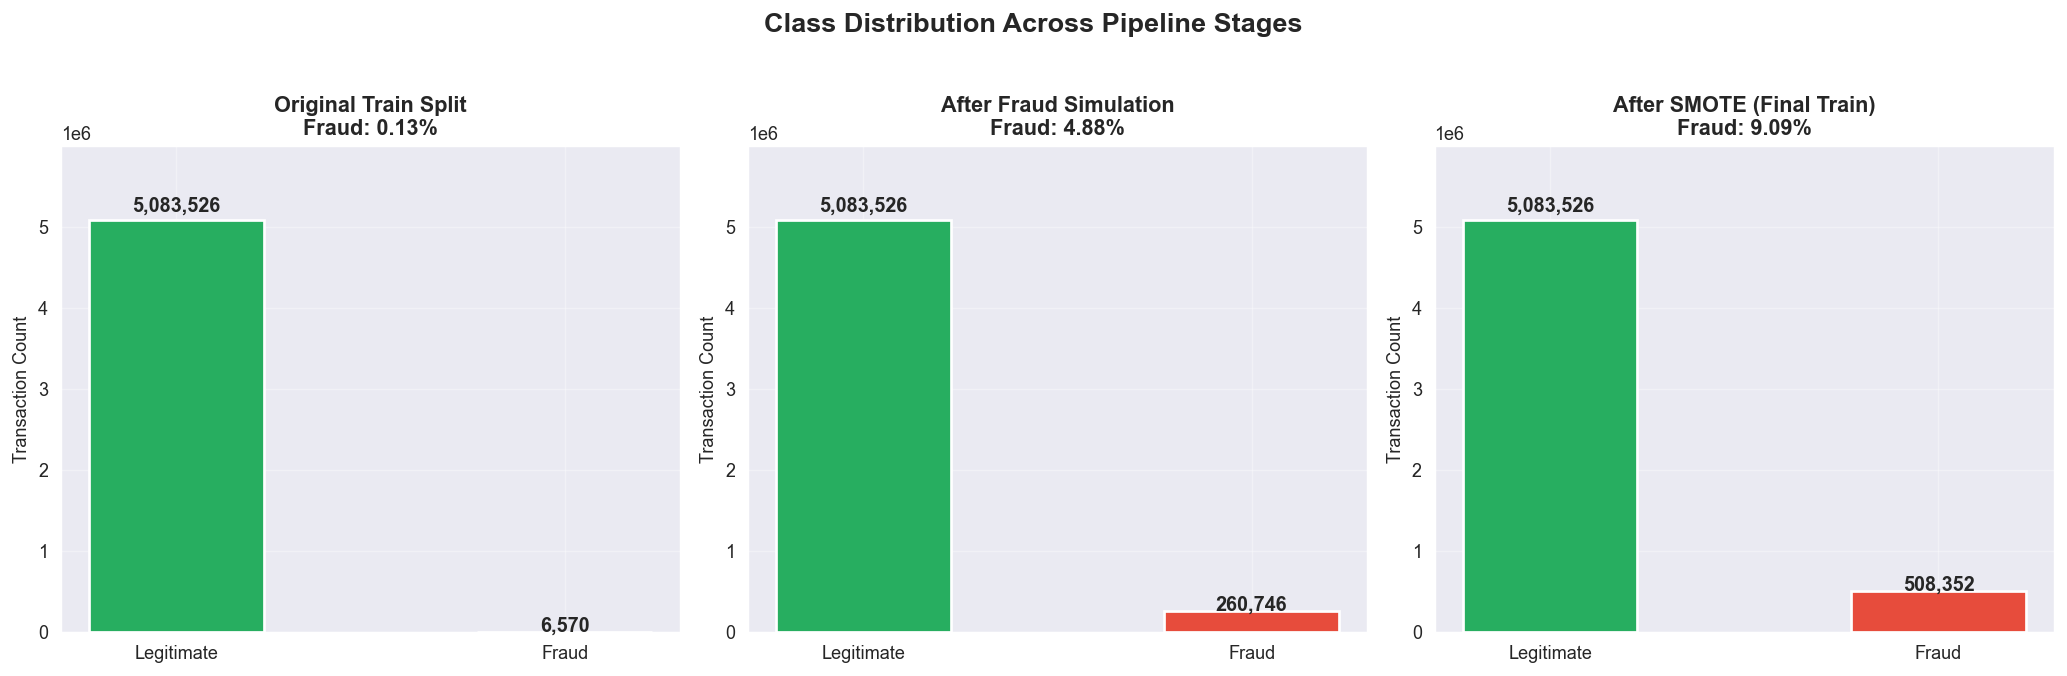

Class distribution chart saved.


In [67]:
# ── EDA: Class distribution at each pipeline stage

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

stages = [
    ("Original Train Split",        y_train),
    ("After Fraud Simulation",      y_train_aug),
    ("After SMOTE (Final Train)",   pd.Series(y_train_smote)),
]

for ax, (title, y_data) in zip(axes, stages):
    counts  = pd.Series(y_data).value_counts().sort_index()
    labels  = ['Legitimate', 'Fraud']
    colors  = [C['green'], C['red']]
    bars    = ax.bar(labels, counts.values, color=colors, width=0.45,
                     edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{val:,}', ha='center', fontsize=11, fontweight='bold')
    pct = counts[1] / counts.sum() * 100
    ax.set_title(f"{title}\nFraud: {pct:.2f}%", fontsize=12, fontweight='bold')
    ax.set_ylabel("Transaction Count", fontsize=10)
    ax.set_ylim(0, counts.max() * 1.18)

fig.suptitle("Class Distribution Across Pipeline Stages", fontsize=15,
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("outputs/plots/eda_class_distribution.png", bbox_inches='tight')
plt.show()
# MEMORY ADDITION #8 — close figure from memory
plt.close('all')
print("Class distribution chart saved.")

In [68]:
# MEMORY ADDITION #9
gc.collect()

12

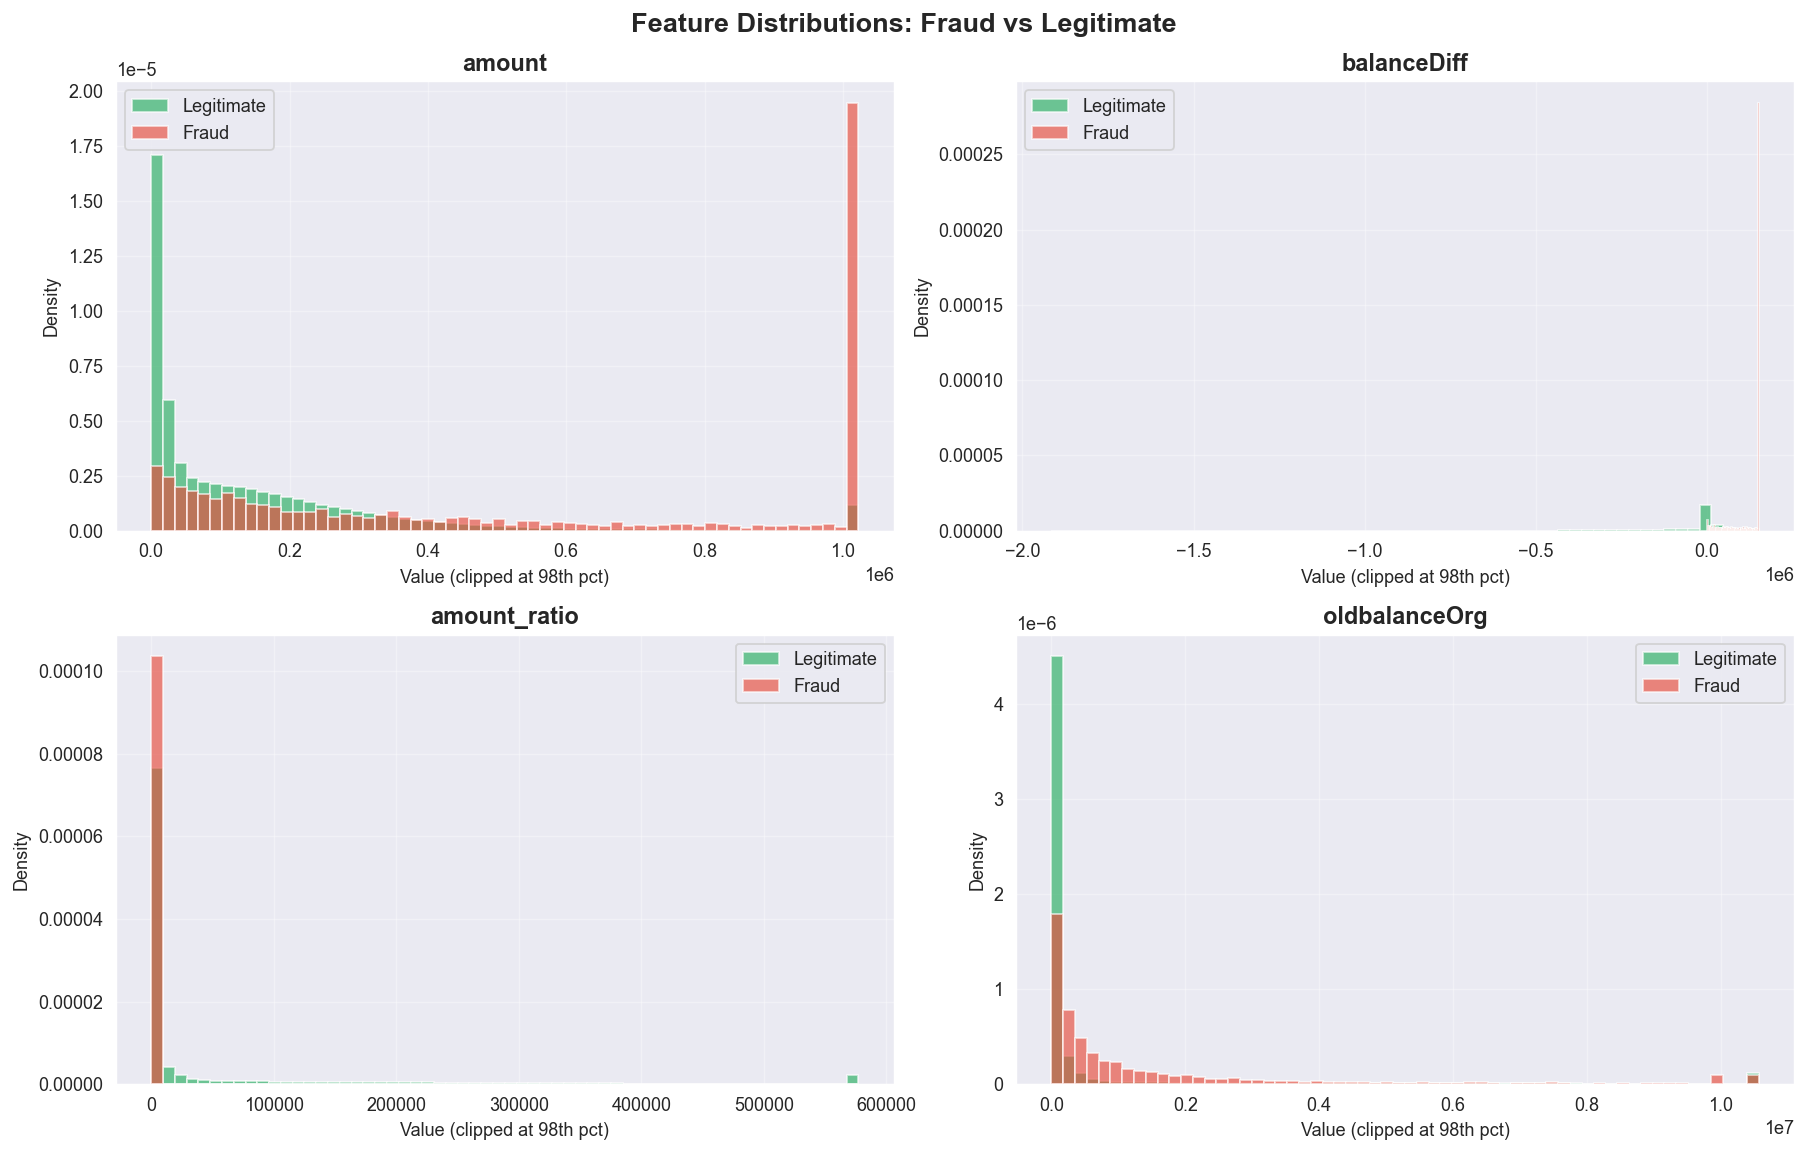

Feature distribution chart saved.


In [69]:
# ── EDA: Feature distributions — fraud vs legitimate

X_eda  = X_train.copy()
X_eda['isFraud'] = y_train.values

plot_cols = ['amount', 'balanceDiff', 'amount_ratio', 'oldbalanceOrg']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    if col in X_eda.columns:
        legit = X_eda[X_eda['isFraud'] == 0][col].clip(
            upper=X_eda[col].quantile(0.98))
        fraud = X_eda[X_eda['isFraud'] == 1][col].clip(
            upper=X_eda[col].quantile(0.98))
        ax.hist(legit, bins=60, color=C['green'], alpha=0.65, label='Legitimate', density=True)
        ax.hist(fraud, bins=60, color=C['red'],   alpha=0.65, label='Fraud',      density=True)
        ax.set_title(col, fontsize=13, fontweight='bold')
        ax.set_xlabel("Value (clipped at 98th pct)", fontsize=10)
        ax.set_ylabel("Density", fontsize=10)
        ax.legend(fontsize=10)

fig.suptitle("Feature Distributions: Fraud vs Legitimate", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/plots/eda_feature_distributions.png", bbox_inches='tight')
plt.show()
# MEMORY ADDITION #10 — close figure from memory
plt.close('all')
gc.collect()
print("Feature distribution chart saved.")

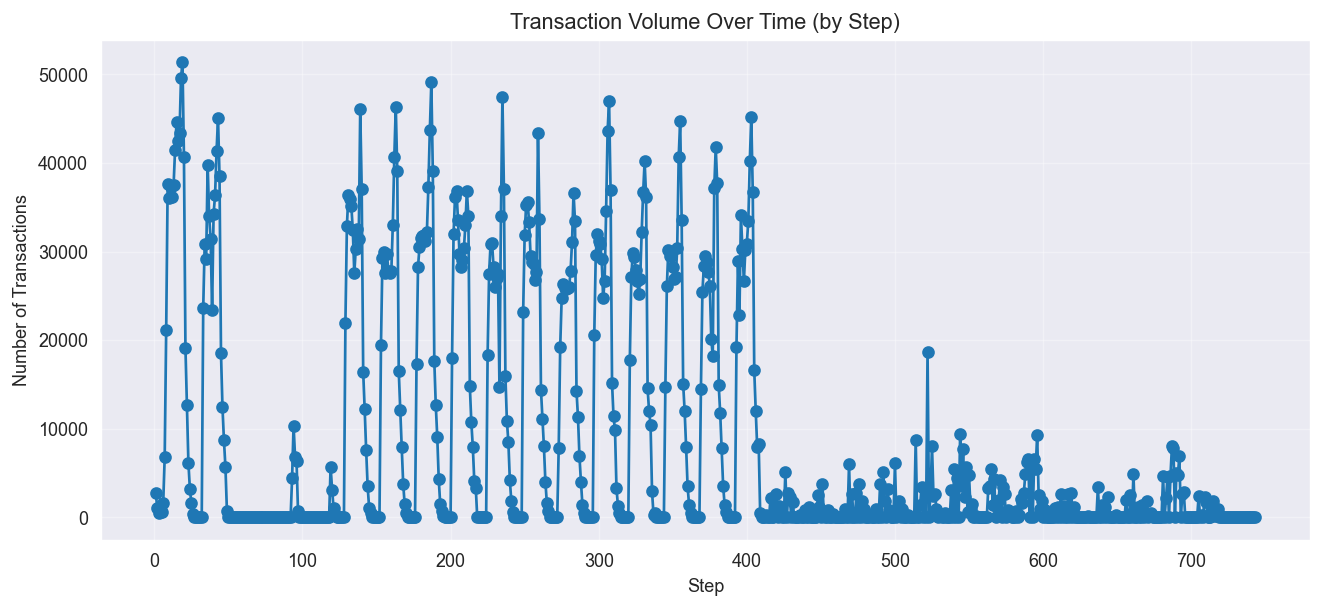

3171

In [70]:
# 1. Transaction Volume Over Time
# Concept: Detect seasonal or temporal trends in transaction activity. Sudden spikes may indicate fraud bursts.
# Technical Insight: Use time-series aggregation of transaction counts by day/week/month.

# The 'transaction_date' column does not exist. Using 'step' as a proxy for time.
time_series = df.groupby('step').size()

plt.figure(figsize=(12,5))
plt.plot(time_series, marker='o')
plt.title('Transaction Volume Over Time (by Step)')
plt.xlabel('Step')
plt.ylabel('Number of Transactions')

plt.grid(True)
plt.savefig("outputs/plots/transaction_volume_over_time.png", dpi=300, bbox_inches="tight")
plt.show()
# MEMORY ADDITION #11 — close figure from memory
plt.close('all')
del time_series
gc.collect()

In [71]:
# 2. Fraudulent vs Legitimate Transaction Distribution
# Concept: Compare class imbalance visually. Essential for imbalanced classification problems.
# Technical Insight: Bar charts or pie charts for categorical understanding.

def fraud_distribution(df_smote):

    plt.figure(figsize=(6,4))
    sns.countplot(
        x="isFraud",
        hue="isFraud",
        data=df_smote,
        order=[0, 1],
        hue_order=[0, 1],
        palette=[C['green'], C['red']],
        legend=False
    )
    plt.xlabel("Transaction Type", fontsize=10)
    plt.ylabel("Number of Transactions", fontsize=10)
    plt.title("Fraud vs Non-Fraud Transactions")
    plt.xticks([0, 1], ['Legitimate', 'Fraud'])
    plt.tight_layout()
    plt.grid(True)

    plt.savefig("outputs/plots/fraud_distribution.png")
    plt.show()
    plt.close('all')

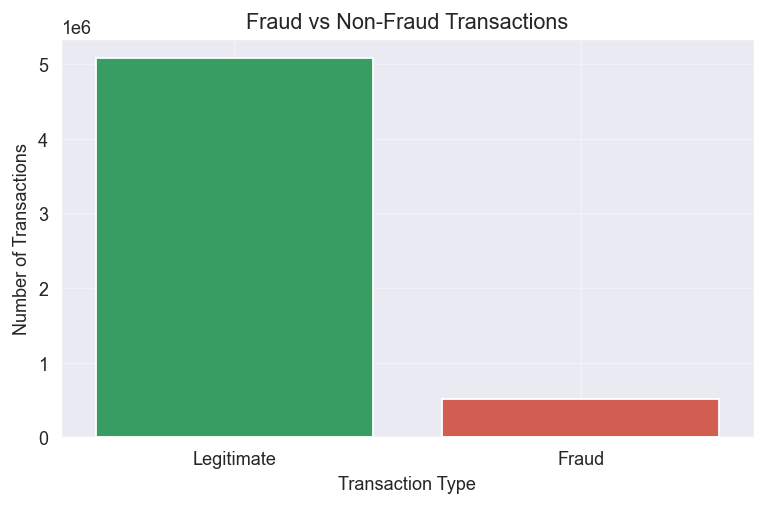

In [72]:
fraud_distribution(df_smote)

In [73]:
# 3. Transaction types Distribution
def transaction_types(df_original, n_rows=30000):
    # Use only first n_rows to speed up plotting and reduce memory usage
    df_plot = df_original.head(n_rows)

    # medium-dark, readable colors (no pink)
    type_palette = ['#2E86C1', '#16A085', '#27AE60', '#E67E22', '#7F8C8D']

    plt.figure(figsize=(8,5))
    sns.countplot(
        x="type",
        hue="type",          # avoids seaborn palette deprecation warning
        data=df_plot,
        palette=type_palette,
        legend=False
    )

    plt.title(f"Transaction Types Distribution (first {len(df_plot):,} rows)")
    plt.xlabel("Transaction Type")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True)
    plt.savefig("outputs/plots/transaction_types_distribution.png")
    plt.show()
    plt.close('all')

Dataset Loaded Successfully
Shape: (6362620, 11)
Memory Usage: 920.71 MB


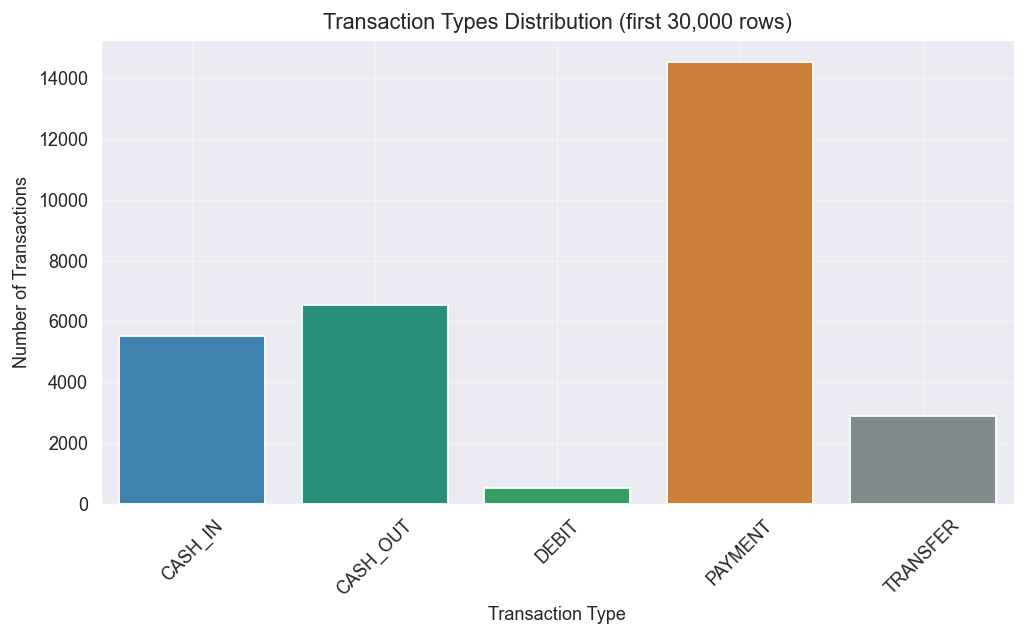

In [74]:
df_original = load_dataset(dataset_path)  # Reload original dataset to avoid memory issues

transaction_types(df_original, 30000)

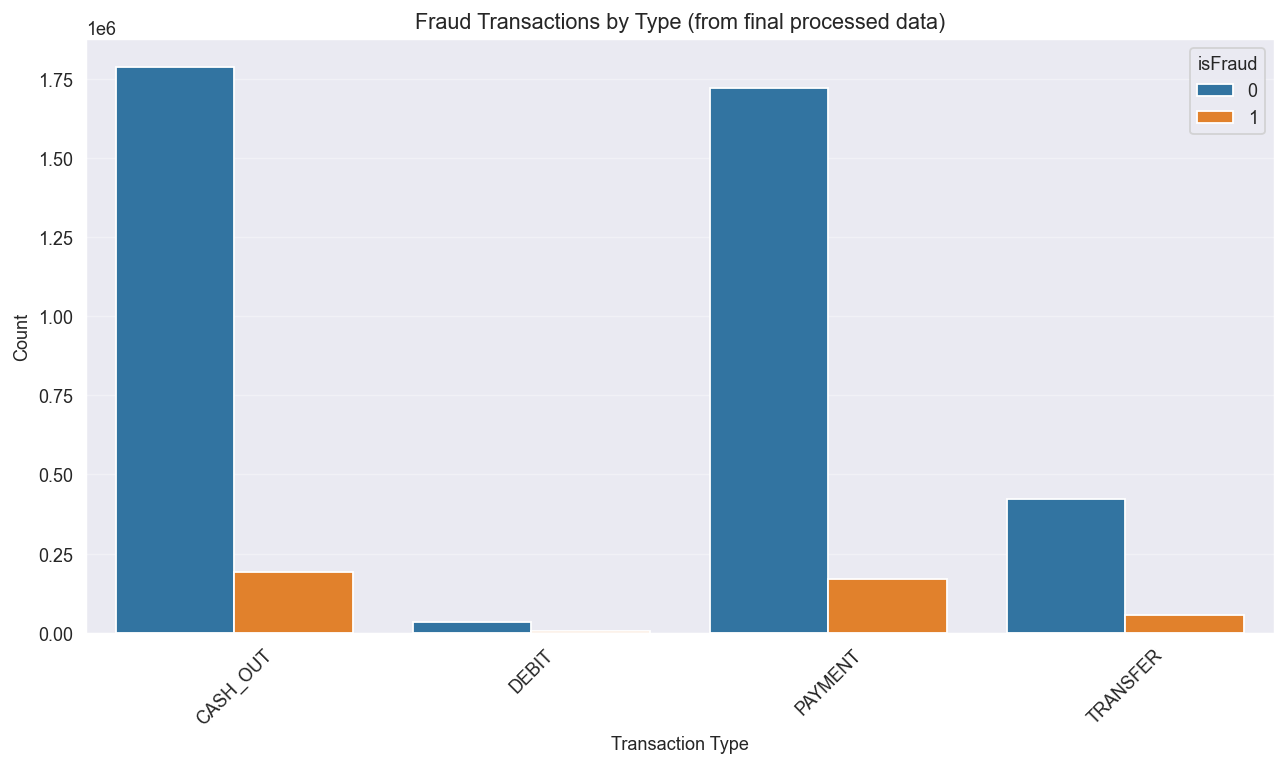

5894

In [75]:
# 4. Fraud Transaction by Type

# Identify the one-hot encoded 'type' columns
type_columns = [col for col in df_smote.columns if col.startswith('type_')]

# Melt the DataFrame to bring the one-hot encoded columns into a single 'variable' column
# and their values into a 'value' column.
# Filter only for rows where 'value' is True (i.e., the transaction is of that type)
df_melted_types = df_smote.melt(id_vars=['isFraud'], value_vars=type_columns, var_name='transaction_type_encoded', value_name='is_this_type')
df_melted_types = df_melted_types[df_melted_types['is_this_type'] == True]

# Rename the transaction_type_encoded to a cleaner 'type' for plotting
df_melted_types['type'] = df_melted_types['transaction_type_encoded'].str.replace('type_', '')

plt.figure(figsize=(10, 6))
sns.countplot(x="type", hue="isFraud", data=df_melted_types)

plt.title("Fraud Transactions by Type (from final processed data)")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/plots/fraud_by_transaction_type.png", dpi=300)
plt.show()

# MEMORY ADDITION #12 — close figure from memory and free melted DataFrame
plt.close('all')
del df_melted_types
gc.collect()

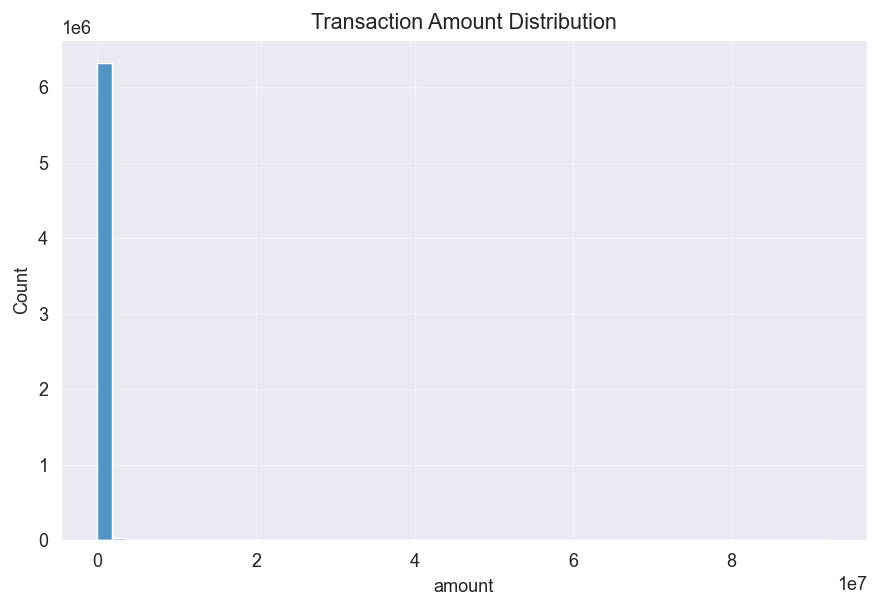

3080

In [76]:
# 5. Transaction Amount Distribution
# Visualizing transaction amount distribution helps understand
# skewness and the need for feature scaling.

plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.savefig("outputs/plots/transaction_amount_distribution.png", dpi=300, bbox_inches="tight")

plt.show()
# MEMORY ADDITION #13 — close figure from memory
plt.close('all')
gc.collect()

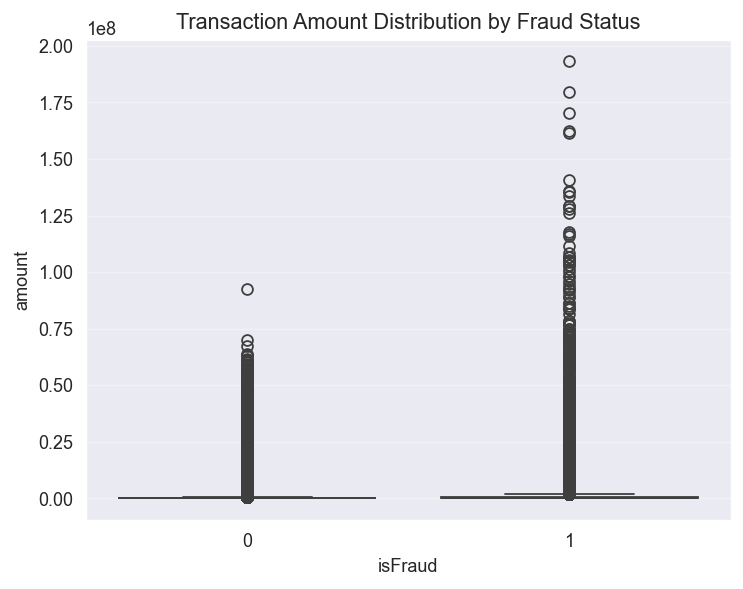

5469

In [77]:
# 6. Transaction Amount Distribution by Fraud Status
# Concept: Fraud often shows unusual transaction amounts.
# Technical Insight: Boxplots or violin plots highlight outliers and distribution skew.

sns.boxplot(x='isFraud', y='amount', data=df_smote)
plt.title('Transaction Amount Distribution by Fraud Status')
plt.savefig("outputs/plots/fraud_vs_normal_transaction_amounts.png", dpi=300, bbox_inches="tight")
plt.show()
# MEMORY ADDITION #14 — close figure from memory
plt.close('all')
gc.collect()

In [78]:
# 8. Correlation Heatmap
# Concept: Identify relationships between numeric features; helps detect potential predictive features.
# Technical Insight: Strong correlations can guide feature engineering or indicate redundancy.
# This heatmao shows the numeric features distribution before scalarization, fraud simulation and SMOTE
def correlation_heatmap(df):

    plt.figure(figsize=(10,8))

    # Select only numerical columns for correlation calculation
    numerical_df = df.select_dtypes(include=[np.number])
    sns.heatmap(numerical_df.corr(), cmap="rocket", annot=True, fmt=".2f")

    plt.title("Feature Correlation Heatmap")

    plt.savefig("outputs/plots/correlation_heatmap_1.png")
    plt.show()
    plt.close('all')

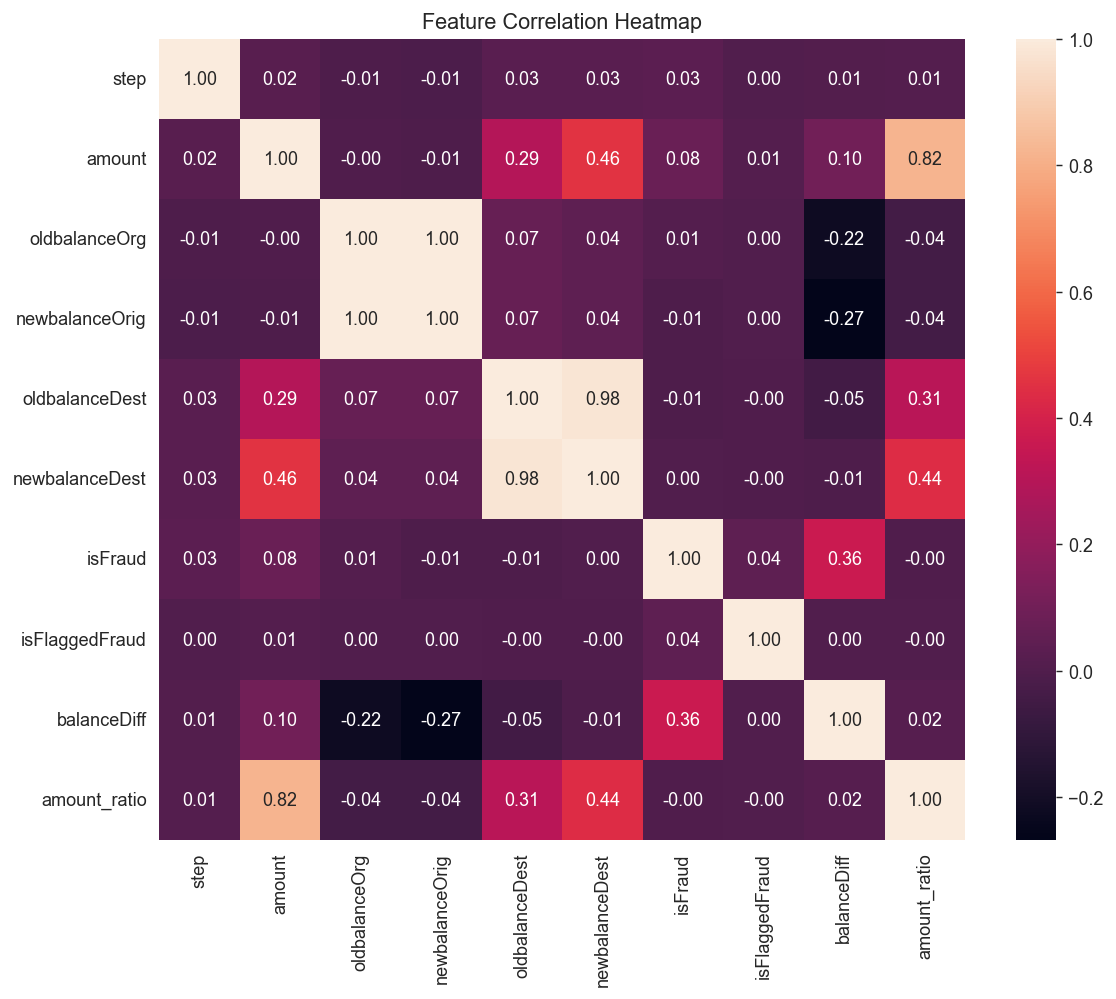

In [79]:
correlation_heatmap(df)

In [80]:
# MEMORY ADDITION #15
gc.collect()

14439

In [81]:
# 10. Top Fraud Patterns (Mean comparison)
def plot_fraud_patterns(df_smote):
    mean_df = df_smote.groupby('isFraud')[['amount', 'balanceDiff']].mean()

    ax = mean_df.plot(
        kind='bar',
        figsize=(8, 5),
        color=[C['blue'], C['orange']],   # reasonable contrasting colors
        edgecolor='white',
        width=0.75
    )

    ax.set_title("Fraud Pattern Comparison")
    ax.set_xlabel("Class")
    ax.set_ylabel("Mean Value")
    ax.set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
    ax.legend(title="Feature")
    plt.tight_layout()

    plt.savefig("outputs/plots/top_fraud_patterns.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close('all')

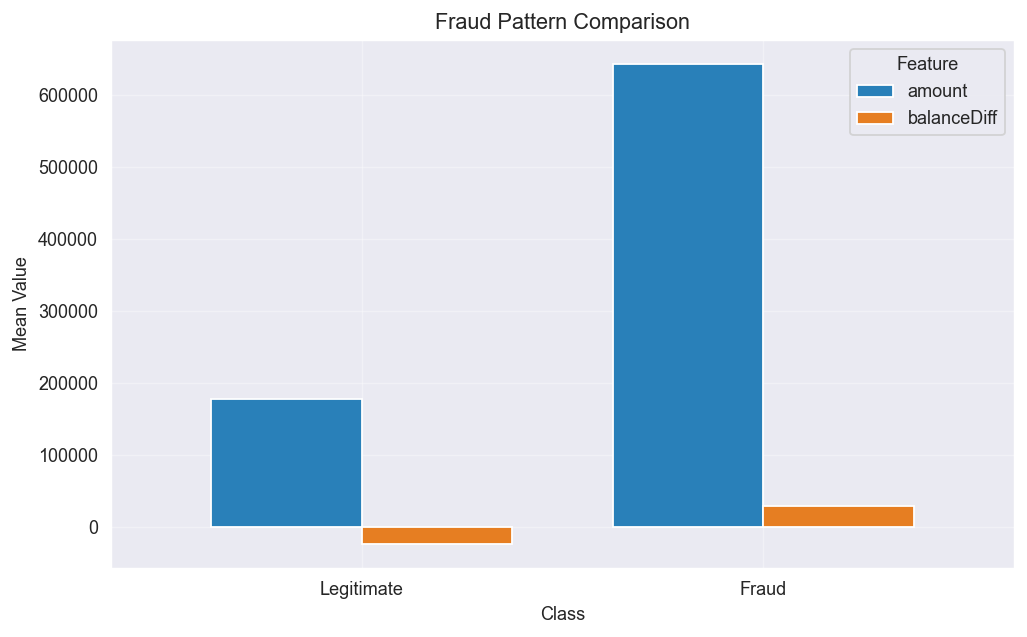

In [82]:
plot_fraud_patterns(df_smote)

In [83]:
# 11. Class Imbalance Visualization
def plot_class_imbalance(df_smote):
    counts = df_smote['isFraud'].value_counts(normalize=True).sort_index()

    ax = counts.plot(
        kind='pie',
        figsize=(6, 6),
        autopct='%1.1f%%',
        startangle=90,
        colors=[C['green'], C['red']],   # Legitimate, Fraud
        labels=['Legitimate', 'Fraud'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
        textprops={'fontsize': 10}
    )

    ax.set_ylabel('')
    plt.title("Class Imbalance Ratio")
    plt.tight_layout()

    plt.savefig("outputs/plots/class_imbalance.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close('all')

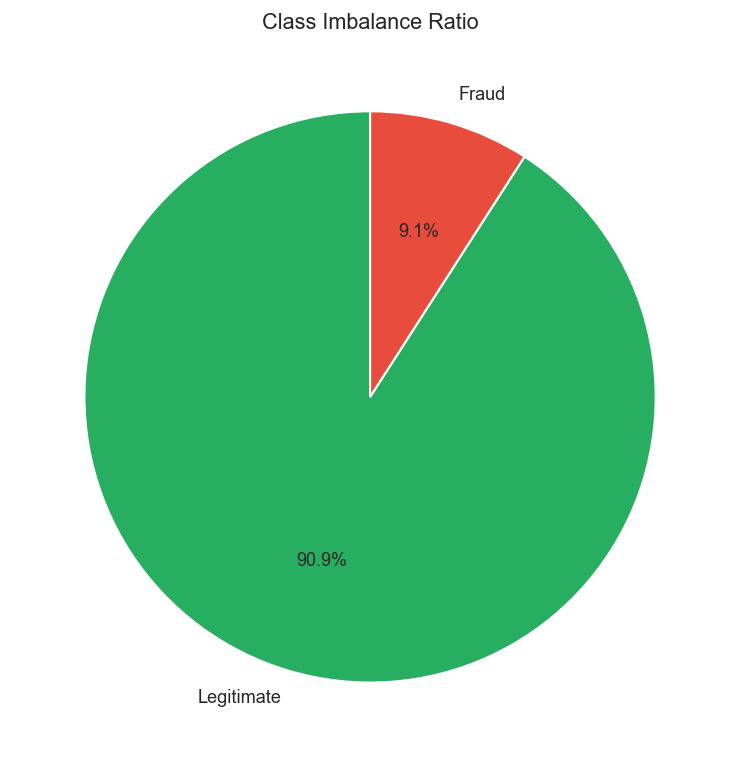

In [84]:
plot_class_imbalance(df_smote)

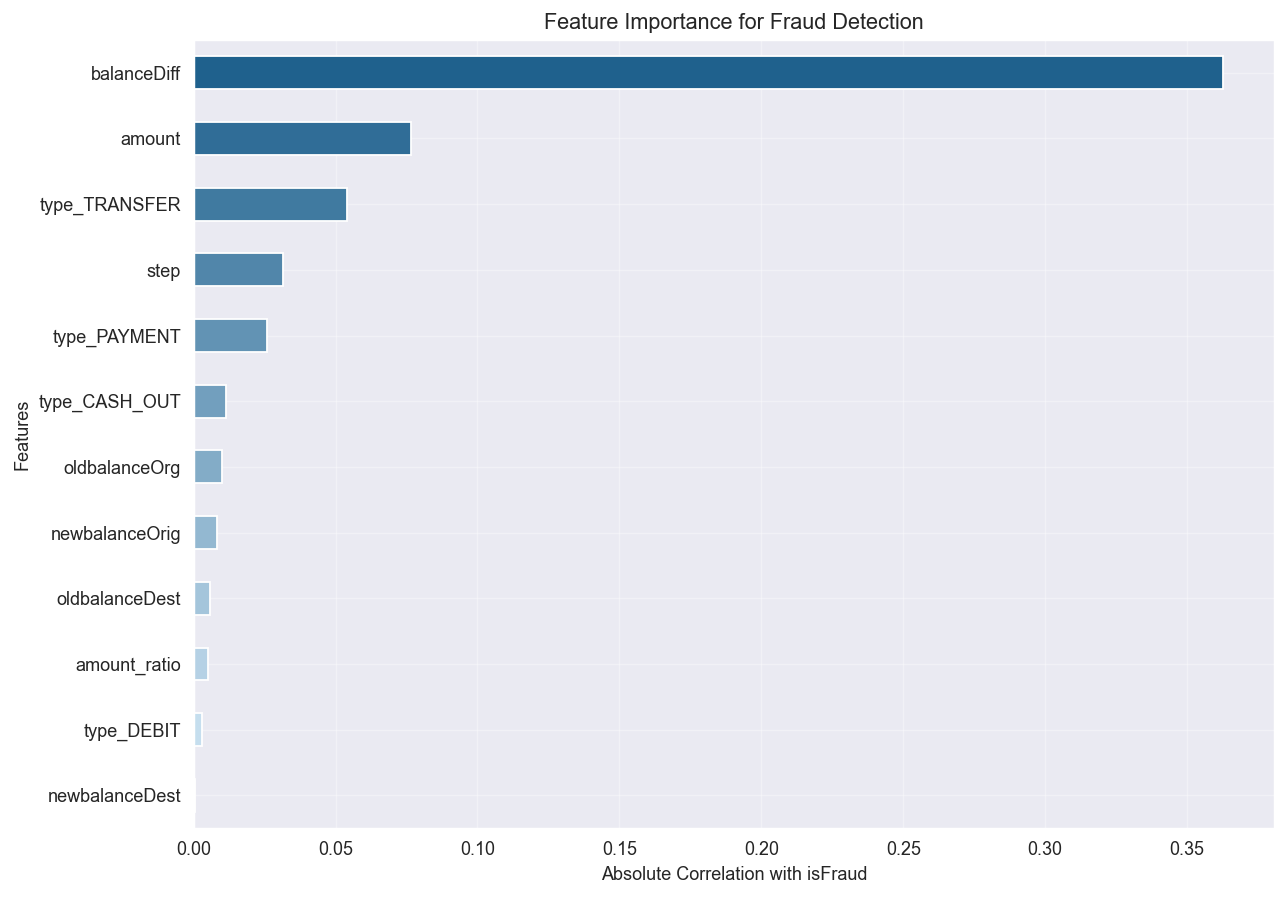

2157

In [85]:
# 14. Feature Importance using Correlation (No ML model needed)
features = df.drop(columns=['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud'])

importances = features.corrwith(df['isFraud']).abs().sort_values()

# soft-to-strong color ramp (low -> high importance)
bar_colors = sns.color_palette("blend:#d6eaf8,#1f618d", n_colors=len(importances))

ax = importances.plot(
    kind='barh',
    figsize=(10, 7),
    color=bar_colors,
    edgecolor='white',
    linewidth=1.0
)

ax.set_title('Feature Importance for Fraud Detection')
ax.set_xlabel('Absolute Correlation with isFraud')
ax.set_ylabel('Features')
plt.tight_layout()

plt.savefig("outputs/plots/feature_importance_1.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close('all')
del features, importances
gc.collect()

In [86]:
print_memory("[AFTER LOAD]")

  Memory Usage [AFTER LOAD]                  :    1,783 MB


In [87]:
## Key Insights from EDA

# - The original dataset exhibited severe class imbalance, with fraudulent transactions representing a very small percentage of the total data. This imbalance was identified as a major challenge for model training.
# - Fraudulent activities were primarily concentrated in specific transaction types, particularly TRANSFER and CASH_OUT, indicating that certain transaction categories carry higher fraud risk.
# - Transaction amounts displayed a highly skewed distribution, with a small number of very large transactions. Fraud cases were often associated with higher transaction amounts and unusual balance changes.
# - Feature engineering, such as the creation of balance difference variables, helped capture hidden transactional anomalies and improved the interpretability of fraud patterns.
# - After applying the fraud simulation engine, the diversity and frequency of fraudulent transactions increased, making fraud patterns more visible and learnable.
# - The application of SMOTE with a sampling ratio of 0.1 significantly improved class balance while maintaining a realistic distribution between fraudulent and non-fraudulent transactions.
# - Comparative analysis between training and testing datasets confirmed that the test set remained untouched, ensuring no data leakage and preserving unbiased evaluation.
# - Feature scaling was applied as the final preprocessing step to standardize numerical features, enabling better performance and stability of machine learning models.
# - Post-processing EDA confirmed that the dataset is now more balanced, structured, and suitable for training robust fraud detection models.

## scripts/save_cleaned_dataset.py
Save the cleaned and preprocessed dataset for future model training and analysis.

In [67]:
# Saving Dataset after doing the cleaning + processing + scalarization + fraud_simulation + SOMET


def save_dataset(df, filename, folder="outputs/processed_data/"):
    """
    Generic save function
    """

    # Ensure the target folder exists
     # Cleaned + Processed Dataset
    os.makedirs(folder, exist_ok=True)

    path = os.path.join(folder, filename)
    df.to_csv(path, index=False)

    print(f"Saved: {path}")
    print(f"Shape: {df.shape}")

In [68]:
save_dataset(df, "processed_paysim.csv")

Saved: outputs/processed_data/processed_paysim.csv
Shape: (6362620, 16)


In [69]:
print(df.head())

   step        amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   9839.639648  C1231006815       170136.0   160296.359375   
1     1   1864.280029  C1666544295        21249.0    19384.720703   
2     1    181.000000  C1305486145          181.0        0.000000   
3     1    181.000000   C840083671          181.0        0.000000   
4     1  11668.139648  C2048537720        41554.0    29885.859375   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  \
0  M1979787155             0.0             0.0        0               0   
1  M2044282225             0.0             0.0        0               0   
2   C553264065             0.0             0.0        1               0   
3    C38997010         21182.0             0.0        1               0   
4  M1230701703             0.0             0.0        0               0   

    balanceDiff  amount_ratio  type_CASH_OUT  type_DEBIT  type_PAYMENT  \
0   9839.640625      0.057834          False       False    

In [70]:
# MEMORY ADDITION #17
gc.collect()

0

In [71]:
def save_pipeline_outputs(df_train, df_test, df_aug, df_final):
    """
    Save all pipeline stages
    """

    print("\n===== SAVING ALL DATASETS =====")

    # 1. Original Train/Test
    save_dataset(df_train, "train_original.csv")
    save_dataset(df_test, "test_original.csv")

    # 2. After Fraud Simulation
    save_dataset(df_aug, "train_after_simulation.csv")

    # 3. After SMOTE (Final Training Data)
    save_dataset(df_final, "train_final_smote.csv")

    print("\n All datasets saved successfully!")

In [72]:
save_pipeline_outputs(df_train, df_test, df_aug, df_final)


===== SAVING ALL DATASETS =====
Saved: outputs/processed_data/train_original.csv
Shape: (6107909, 13)
Saved: outputs/processed_data/test_original.csv
Shape: (1272524, 13)
Saved: outputs/processed_data/train_after_simulation.csv
Shape: (5344272, 13)
Saved: outputs/processed_data/train_final_smote.csv
Shape: (5591878, 13)

 All datasets saved successfully!


In [73]:
print(df_final.head())

       step    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0 -1.615976 -0.236840      -0.273735       -0.280670       -0.322519   
1 -1.580610 -0.240273      -0.289055       -0.292417       -0.322519   
2 -0.088159  0.157243      -0.289055       -0.292417       -0.179004   
3 -0.052793 -0.240016      -0.289055       -0.292417       -0.322519   
4 -0.710603 -0.003389       4.227685        4.245858        0.391948   

   newbalanceDest  balanceDiff  amount_ratio  type_CASH_OUT  type_DEBIT  \
0       -0.332461     0.167796     -0.109959      -0.740139   -0.082274   
1       -0.332461     0.108850     -0.101549      -0.740139   -0.082274   
2       -0.101614     0.108850      0.333219       1.351097   -0.082274   
3       -0.332461     0.108850     -0.101268      -0.740139   -0.082274   
4        0.269806    -1.187343     -0.109959      -0.740139   -0.082274   

   type_PAYMENT  type_TRANSFER  isFraud  
0      1.399297      -0.306418        0  
1      1.399297      -0.306418  

In [74]:
# MEMORY ADDITION #18 — Final garbage collection after all EDA and saving is done, to free any remaining large objects
gc.collect()

print_memory("[BEFORE MODEL TRAINING — AFTER CLEANUP]")

  Memory Usage [BEFORE MODEL TRAINING — AFTER CLEANUP]:    2,202 MB


## Summary

The PaySim dataset was analyzed and processed to understand transaction behavior and improve fraud detection capability. Initial analysis revealed that fraudulent activities were primarily concentrated in **TRANSFER** and **CASH_OUT** transaction types, with fraud cases often involving unusually large transaction amounts and abnormal balance changes, such as accounts being completely drained or destination accounts showing inconsistent balances.

First, data cleaning and feature engineering were performed to enhance data quality and extract meaningful patterns, including features capturing balance differences and transactional anomalies. The dataset was then split early into training and testing sets to prevent data leakage and ensure reliable evaluation.

To improve fraud representation, a **Fraud Simulation Engine** was introduced as a core innovation. This step generated additional synthetic fraud transactions based on observed behavioral patterns, increasing both the diversity and realism of fraud cases.

Following this, **SMOTE (Synthetic Minority Oversampling Technique)** was applied with a sampling ratio of **0.1**, increasing the proportion of fraudulent transactions while maintaining a realistic imbalance. This approach ensured that the model can learn fraud patterns effectively without overfitting to artificially balanced data.

Finally, feature scaling was applied using training-based parameters to standardize numerical features, improving model performance and stability.

---
---
# Phase 3 and 4: Model Architecture & Implementation

This phase implements **four machine learning models** for binary fraud classification.  
Each model is built with justified hyperparameters, followed by **5-Fold Stratified Cross-Validation** and held-out test evaluation.

Logistic Regression, Random Forest, XGBoost, Neural Network (MLP)

## scripts/hyperparameter_config.py
Document and justify every hyperparameter for all four models.

In [66]:
# 1. CONFIGURATION

MODEL_SAVE_PATH = "outputs/models/"
METRICS_SAVE_PATH = "outputs/metrics/"

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(METRICS_SAVE_PATH, exist_ok=True)

In [67]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Standard evaluation function for ALL models
    Ensures fair comparison across models
    """

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_prob)
    ap     = average_precision_score(y_test, y_prob)


    metrics = {
        "model_name"   : model_name,
        "test_accuracy": report['accuracy'],
        "test_precision": report['1']['precision'],
        "test_recall"   : report['1']['recall'],
        "test_f1"       : report['1']['f1-score'],
        "test_auc_roc"  : auc,
        "test_avg_prec" : ap,
        "y_pred"        : y_pred,
        "y_prob"        : y_prob,
    }

    print(f"\n{'='*52}")
    print(f"  {model_name.upper()} — Test Set Results")
    print(f"{'='*52}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Legitimate', 'Fraud']))
    print(f"  AUC-ROC        : {auc:.4f}")
    print(f"  Avg Precision  : {ap:.4f}")

    return metrics

## scripts/kfold_validation.py
Implement 5-Fold Stratified Cross-Validation for robust performance estimation.

In [68]:
def run_kfold(model, X_train, y_train, model_name, n_splits=3):
    """
    Run Stratified K-Fold Cross-Validation.
    Returns mean and std of Precision, Recall, F1-Score, AUC-ROC.
    """
    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scoring = ['precision', 'recall', 'f1', 'roc_auc']

    results = cross_validate(
        model, X_train, y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    print(f"\n{'─'*52}")
    print(f"  K-Fold CV ({n_splits}-Fold): {model_name.upper()}")
    print(f"{'─'*52}")
    for metric in scoring:
        s = results[f'test_{metric}']
        print(f"  {metric:<15}: {s.mean():.4f}  ±  {s.std():.4f}")

    return {
        "model"            : model_name,
        "cv_precision_mean": results['test_precision'].mean(),
        "cv_precision_std" : results['test_precision'].std(),
        "cv_recall_mean"   : results['test_recall'].mean(),
        "cv_recall_std"    : results['test_recall'].std(),
        "cv_f1_mean"       : results['test_f1'].mean(),
        "cv_f1_std"        : results['test_f1'].std(),
        "cv_auc_mean"      : results['test_roc_auc'].mean(),
        "cv_auc_std"       : results['test_roc_auc'].std(),
    }

## scripts/logistic_regression.py

In [69]:
print_memory("[READY FOR/BEFORE TRAINING OF ALL MODELS]")

  Memory Usage [READY FOR/BEFORE TRAINING OF ALL MODELS]:      862 MB


In [70]:
def run_logistic(X_train, X_test, y_train, y_test):
    """
    Logistic Regression:
    - Baseline model
    - Explainability reference
    """

    model = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C           = 1.0,
        solver      = 'lbfgs',
        random_state= 42,
    )
    cv_metrics   = run_kfold(model, X_train, y_train, "logistic_regression")

    model.fit(X_train, y_train)

    # Evaluate
    test_metrics = evaluate_model(model, X_test, y_test, "logistic_regression")

    # Save model
    joblib.dump(model, "outputs/models/logistic_regression.pkl")
    joblib.dump({**cv_metrics, **test_metrics}, "outputs/metrics/logistic_regression.csv")

    return model, {**cv_metrics, **test_metrics}

In [71]:
# CELL 38 — Convert to numpy for sklearn
# Convert to numpy for sklearn compatibility
X_tr = X_train_final.values.astype('float32')  # 4 bytes per value
X_ts = X_test_final.values.astype('float32')   # 4 bytes per value
y_tr = np.array(y_train_smote, dtype='int8')   # 1 byte per value
y_ts = np.array(y_test, dtype='int8')          # 1 byte per value
# Memory reduced by ~50%!

print(f"Training set : {X_tr.shape}  |  fraud ratio: {y_tr.mean():.4f}")
print(f"Test set     : {X_ts.shape}  |  fraud ratio: {y_ts.mean():.4f}")

Training set : (5591878, 12)  |  fraud ratio: 0.0909
Test set     : (1272524, 12)  |  fraud ratio: 0.0013


In [72]:
lr_model,  lr_metrics  = run_logistic(X_tr, X_ts, y_tr, y_ts)
print("\nLogistic Regression Model trained and saved.")


────────────────────────────────────────────────────
  K-Fold CV (3-Fold): LOGISTIC_REGRESSION
────────────────────────────────────────────────────
  precision      : 0.3750  ±  0.0013
  recall         : 0.6959  ±  0.0020
  f1             : 0.4874  ±  0.0006
  roc_auc        : 0.8827  ±  0.0001

  LOGISTIC_REGRESSION — Test Set Results
              precision    recall  f1-score   support

  Legitimate       1.00      0.88      0.94   1270881
       Fraud       0.01      0.81      0.02      1643

    accuracy                           0.88   1272524
   macro avg       0.50      0.84      0.48   1272524
weighted avg       1.00      0.88      0.94   1272524

  AUC-ROC        : 0.9035
  Avg Precision  : 0.5045

Logistic Regression Model trained and saved.


In [73]:
# FIX: Keep X_train_final, X_test_final, y_train_smote alive for later model cells
# Removed: del X_train_final, X_test_final, y_train_smote
gc.collect()

2619

## scripts/random_forest.py

In [74]:
def run_random_forest(X_train, X_test, y_train, y_test):
    """
    Random Forest:
    - Captures non-linear patterns
    - Feature interactions
    """

    model = RandomForestClassifier(
        n_estimators=50,
        max_depth=7,
        min_samples_split= 50,
        min_samples_leaf = 10,
        max_features    = 'sqrt',           # ADD: faster feature search
        max_samples     = 0.4, 
        class_weight    = 'balanced',
        random_state=42,
        n_jobs=-1,
    )

    cv_metrics   = run_kfold(model, X_train, y_train, "random_forest")

    model.fit(X_train, y_train)

    test_metrics = evaluate_model(model, X_test, y_test, "random_forest")

    joblib.dump(model, "outputs/models/random_forest.pkl")
    joblib.dump({**cv_metrics, **test_metrics}, "outputs/metrics/random_forest.csv")

    return model, {**cv_metrics, **test_metrics}

In [75]:
# Convert to numpy for sklearn compatibility
X_tr = X_train_final.values.astype('float32')  # 4 bytes per value
X_ts = X_test_final.values.astype('float32')   # 4 bytes per value
y_tr = np.array(y_train_smote, dtype='int8')   # 1 byte per value
y_ts = np.array(y_test, dtype='int8')          # 1 byte per value
# Memory reduced by ~50%!

print(f"Training set : {X_tr.shape}  |  fraud ratio: {y_tr.mean():.4f}")
print(f"Test set     : {X_ts.shape}  |  fraud ratio: {y_ts.mean():.4f}")

Training set : (5591878, 12)  |  fraud ratio: 0.0909
Test set     : (1272524, 12)  |  fraud ratio: 0.0013


In [76]:
rf_model,  rf_metrics  = run_random_forest(X_tr, X_ts, y_tr, y_ts)
print("\nRandom Forest Model trained and saved.")


────────────────────────────────────────────────────
  K-Fold CV (3-Fold): RANDOM_FOREST
────────────────────────────────────────────────────
  precision      : 0.5384  ±  0.0078
  recall         : 0.8018  ±  0.0065
  f1             : 0.6441  ±  0.0036
  roc_auc        : 0.9441  ±  0.0014

  RANDOM_FOREST — Test Set Results
              precision    recall  f1-score   support

  Legitimate       1.00      0.93      0.96   1270881
       Fraud       0.01      0.73      0.03      1643

    accuracy                           0.93   1272524
   macro avg       0.51      0.83      0.50   1272524
weighted avg       1.00      0.93      0.96   1272524

  AUC-ROC        : 0.8621
  Avg Precision  : 0.2032

Random Forest Model trained and saved.


In [77]:
# MEMORY ADDITION #20
gc.collect()

68

## scripts/xgboost_regression.py

In [78]:
def run_xgboost(X_train, X_test, y_train, y_test):
    """
    XGBoost:
    - Main fraud detection model
    - Best performance for tabular data
    """

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight= 3,
        gamma           = 0.1,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    cv_metrics   = run_kfold(model, X_train, y_train, "xgboost")

    model.fit(X_train, y_train)

    test_metrics = evaluate_model(model, X_test, y_test, "xgboost")

    joblib.dump(model, "outputs/models/xgboost.pkl")
    joblib.dump({**cv_metrics, **test_metrics}, "outputs/metrics/xgboost_classifier.csv")

    return model, {**cv_metrics, **test_metrics}

In [79]:
# Convert to numpy for sklearn compatibility
X_tr = X_train_final.values.astype('float32')  # 4 bytes per value
X_ts = X_test_final.values.astype('float32')   # 4 bytes per value
y_tr = np.array(y_train_smote, dtype='int8')   # 1 byte per value
y_ts = np.array(y_test, dtype='int8')          # 1 byte per value
# Memory reduced by ~50%!

print(f"Training set : {X_tr.shape}  |  fraud ratio: {y_tr.mean():.4f}")
print(f"Test set     : {X_ts.shape}  |  fraud ratio: {y_ts.mean():.4f}")

Training set : (5591878, 12)  |  fraud ratio: 0.0909
Test set     : (1272524, 12)  |  fraud ratio: 0.0013


In [80]:
xgb_model, xgb_metrics = run_xgboost(X_tr, X_ts, y_tr, y_ts)
print("\nXGBOOST Model trained and saved.")


────────────────────────────────────────────────────
  K-Fold CV (3-Fold): XGBOOST
────────────────────────────────────────────────────
  precision      : 0.9921  ±  0.0002
  recall         : 0.8708  ±  0.0042
  f1             : 0.9275  ±  0.0023
  roc_auc        : 0.9960  ±  0.0002

  XGBOOST — Test Set Results
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00   1270881
       Fraud       0.15      0.95      0.26      1643

    accuracy                           0.99   1272524
   macro avg       0.58      0.97      0.63   1272524
weighted avg       1.00      0.99      1.00   1272524

  AUC-ROC        : 0.9979
  Avg Precision  : 0.8517

XGBOOST Model trained and saved.


In [81]:
# MEMORY ADDITION #21
gc.collect()

250

## scripts/nueral_networks.py

In [85]:
def run_neural_network(X_train, X_test, y_train, y_test):
    """
    Neural Network:
    - Optional advanced model
    """

    model = MLPClassifier(
        hidden_layer_sizes = (64, 32),
        activation         = 'relu',
        solver             = 'adam',
        alpha              = 0.001,
        batch_size         = 512,
        learning_rate_init = 0.001,
        max_iter           = 50,
        early_stopping     = True,
        n_iter_no_change   = 5,
        random_state       = 42,
    )

    cv_metrics   = run_kfold(model, X_train, y_train, "neural_network")

    model.fit(X_train, y_train)

    test_metrics = evaluate_model(model, X_test, y_test, "neural_network")

    joblib.dump(model, "outputs/models/neural_network.pkl")
    joblib.dump({**cv_metrics, **test_metrics}, "outputs/metrics/neural_network.csv")

    return model, {**cv_metrics, **test_metrics}

In [86]:
# Convert to numpy for sklearn compatibility
X_tr = X_train_final.values.astype('float32')  # 4 bytes per value
X_ts = X_test_final.values.astype('float32')   # 4 bytes per value
y_tr = np.array(y_train_smote, dtype='int8')   # 1 byte per value
y_ts = np.array(y_test, dtype='int8')          # 1 byte per value
# Memory reduced by ~50%!

print(f"Training set : {X_tr.shape}  |  fraud ratio: {y_tr.mean():.4f}")
print(f"Test set     : {X_ts.shape}  |  fraud ratio: {y_ts.mean():.4f}")

Training set : (5591878, 12)  |  fraud ratio: 0.0909
Test set     : (1272524, 12)  |  fraud ratio: 0.0013


In [87]:
nn_model,  nn_metrics  = run_neural_network(X_tr, X_ts, y_tr, y_ts)
print("\n Neural Network Model trained and saved.")


────────────────────────────────────────────────────
  K-Fold CV (3-Fold): NEURAL_NETWORK
────────────────────────────────────────────────────
  precision      : 0.9875  ±  0.0037
  recall         : 0.9246  ±  0.0091
  f1             : 0.9550  ±  0.0038
  roc_auc        : 0.9967  ±  0.0007

  NEURAL_NETWORK — Test Set Results
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1270881
       Fraud       0.64      0.76      0.69      1643

    accuracy                           1.00   1272524
   macro avg       0.82      0.88      0.85   1272524
weighted avg       1.00      1.00      1.00   1272524

  AUC-ROC        : 0.9921
  Avg Precision  : 0.7778

 Neural Network Model trained and saved.


In [88]:
# MEMORY ADDITION #22
gc.collect()
print_memory("[AFTER ALL MODELS TRAINED]")

  Memory Usage [AFTER ALL MODELS TRAINED]    :      621 MB


## scripts/visualize_confusion_matrix.py
Plot annotated confusion matrices for all four models.

In [89]:
ALL_MODELS  = {
    "Logistic Regression": lr_model,
    "Random Forest"      : rf_model,
    "XGBoost"            : xgb_model,
    "Neural Network"     : nn_model,
}
ALL_METRICS = {
    "Logistic Regression": lr_metrics,
    "Random Forest"      : rf_metrics,
    "XGBoost"            : xgb_metrics,
    "Neural Network"     : nn_metrics,
}

In [90]:
def plot_confusion_matrices(all_models, X_test, y_test):
    """
    Plot confusion matrices for all models in a 2×2 grid.
    Each cell shows count and row-normalised percentage.
    """
    cmaps  = ['Greens', 'Blues', 'Oranges', 'Purples']
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    axes = axes.flatten()

    for i, ((name, model), cmap) in enumerate(zip(all_models.items(), cmaps)):
        y_pred       = model.predict(X_test)
        cm           = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        cm_norm      = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_norm, ax=axes[i], cmap=cmap,
                    annot=False, fmt='.2f',
                    linewidths=2, linecolor='white',
                    cbar_kws={'shrink': 0.75, 'label': 'Row-normalised rate'},
                    vmin=0, vmax=1)

        cell_data = [
            [f"TN\n{tn:,}\n{cm_norm[0,0]:.1%}", f"FP\n{fp:,}\n{cm_norm[0,1]:.1%}"],
            [f"FN\n{fn:,}\n{cm_norm[1,0]:.1%}", f"TP\n{tp:,}\n{cm_norm[1,1]:.1%}"],
        ]
        for r in range(2):
            for c in range(2):
                txt_color = 'white' if cm_norm[r, c] > 0.55 else '#2c3e50'
                axes[i].text(c + 0.5, r + 0.5, cell_data[r][c],
                             ha='center', va='center',
                             fontsize=11, fontweight='bold', color=txt_color)

        axes[i].set_title(name, fontsize=14, fontweight='bold', pad=12)
        axes[i].set_xlabel("Predicted Label", fontsize=11)
        axes[i].set_ylabel("True Label",      fontsize=11)
        axes[i].set_xticklabels(['Legitimate', 'Fraud'], fontsize=10)
        axes[i].set_yticklabels(['Legitimate', 'Fraud'], fontsize=10, rotation=0)

    fig.suptitle("Confusion Matrices — All Models", fontsize=17,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("outputs/plots/confusion_matrices.png", bbox_inches='tight')
    plt.show()
    plt.close('all')
    print("Confusion matrices saved.")

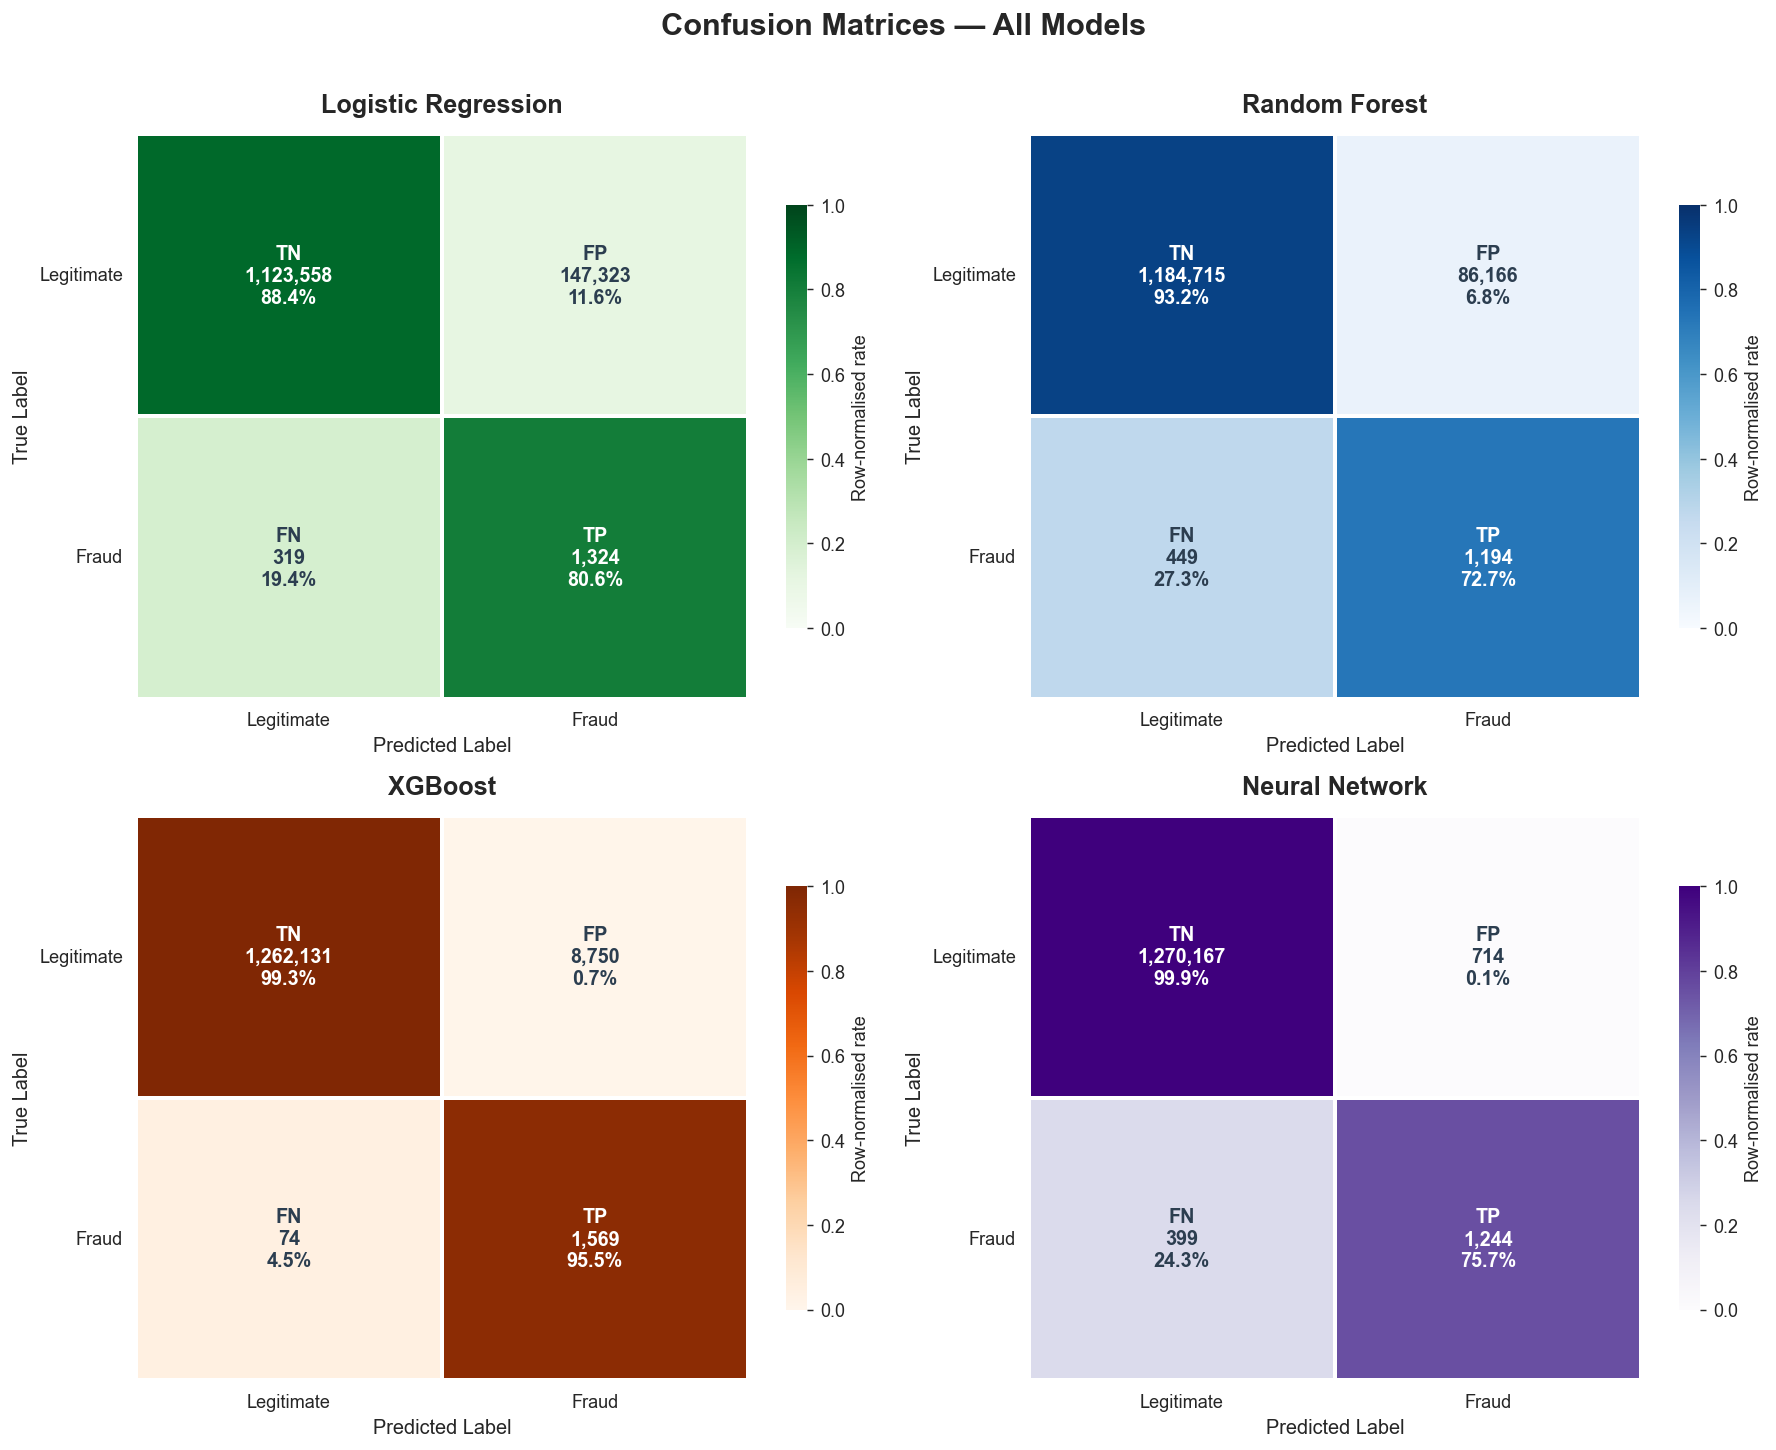

Confusion matrices saved.


In [91]:
plot_confusion_matrices(ALL_MODELS, X_ts, y_ts)

## scripts/roc_curves.py
Plot ROC and Precision-Recall curves for all models on a single canvas.

In [92]:
def plot_roc_pr_curves(all_models, X_test, y_test):
    """
    Side-by-side ROC curve and Precision-Recall curve for all models.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for (name, model), color in zip(all_models.items(), MODEL_COLORS):
        y_prob = model.predict_proba(X_test)[:, 1]

        # ── ROC
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc         = roc_auc_score(y_test, y_prob)
        axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                     label=f"{name}  (AUC = {auc:.3f})")

        # ── Precision-Recall
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        ap           = average_precision_score(y_test, y_prob)
        axes[1].plot(rec, prec, color=color, linewidth=2.5,
                     label=f"{name}  (AP = {ap:.3f})")

    # ROC reference line
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.5,
                 label='Random Classifier')
    axes[0].fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
    axes[0].set_title("ROC Curves", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("False Positive Rate", fontsize=12)
    axes[0].set_ylabel("True Positive Rate",  fontsize=12)
    axes[0].legend(fontsize=10, loc='lower right')

    # PR baseline
    baseline = y_test.mean()
    axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1.2,
                    alpha=0.5, label=f'No-Skill Baseline ({baseline:.3f})')
    axes[1].set_title("Precision-Recall Curves", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Recall",    fontsize=12)
    axes[1].set_ylabel("Precision", fontsize=12)
    axes[1].legend(fontsize=10, loc='upper right')

    fig.suptitle("Model Discrimination Curves", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("outputs/plots/roc_pr_curves.png", bbox_inches='tight')
    plt.show()
    plt.close('all')
    print("ROC and Precision-Recall curves saved.")

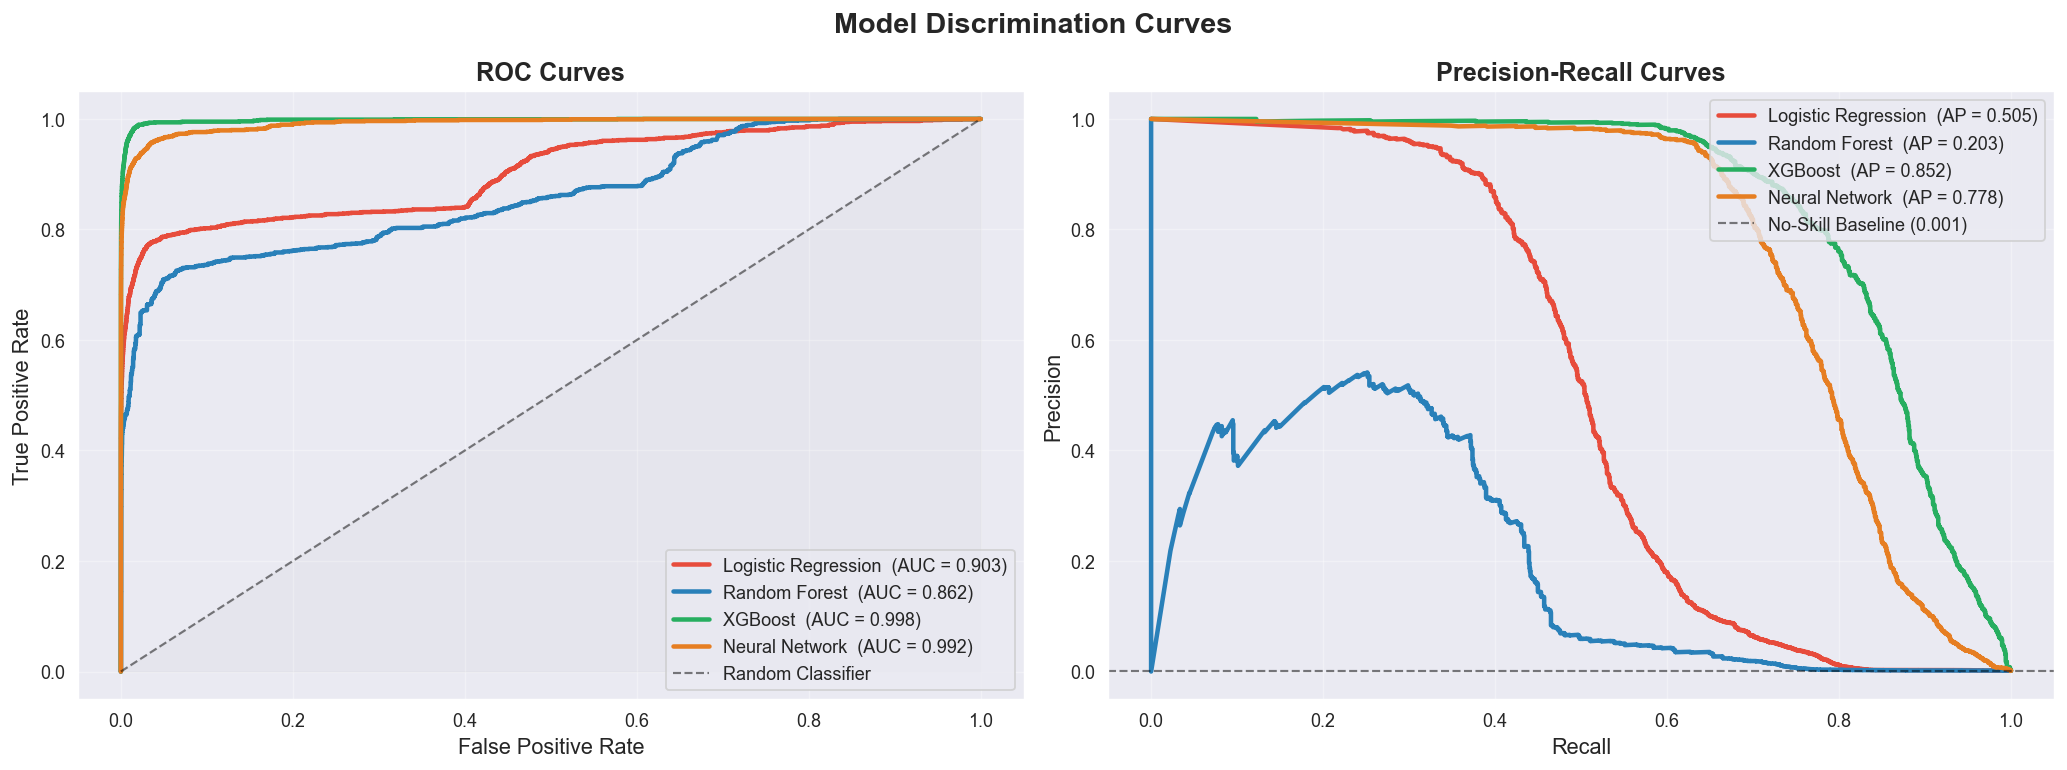

ROC and Precision-Recall curves saved.


In [93]:
plot_roc_pr_curves(ALL_MODELS, X_ts, y_ts)

## scripts/feature_importance.py
Analyse which features contribute most to fraud detection in tree-based models.

In [94]:
def plot_feature_importance(rf_model, xgb_model, feature_names, top_n=12):
    """
    Horizontal bar chart of feature importances for RF and XGBoost.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, model, name, color in zip(
        axes,
        [rf_model, xgb_model],
        ["Random Forest", "XGBoost"],
        [C['blue'], C['orange']],
    ):
        importances  = model.feature_importances_
        top_idx      = np.argsort(importances)[-top_n:]
        top_features = [feature_names[i] for i in top_idx]
        top_vals     = importances[top_idx]

        bars = ax.barh(top_features, top_vals, color=color,
                       edgecolor='white', linewidth=0.8, height=0.65)

        for bar, val in zip(bars, top_vals):
            ax.text(bar.get_width() + 0.0005,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.4f}', va='center', fontsize=9)

        ax.set_title(f"{name}", fontsize=13, fontweight='bold')
        ax.set_xlabel("Importance Score", fontsize=11)
        ax.set_xlim(0, top_vals.max() * 1.2)

    fig.suptitle(f"Top-{top_n} Feature Importances", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("outputs/plots/feature_importance.png", bbox_inches='tight')
    plt.show()
    plt.close('all')
    print("Feature importance charts saved.")

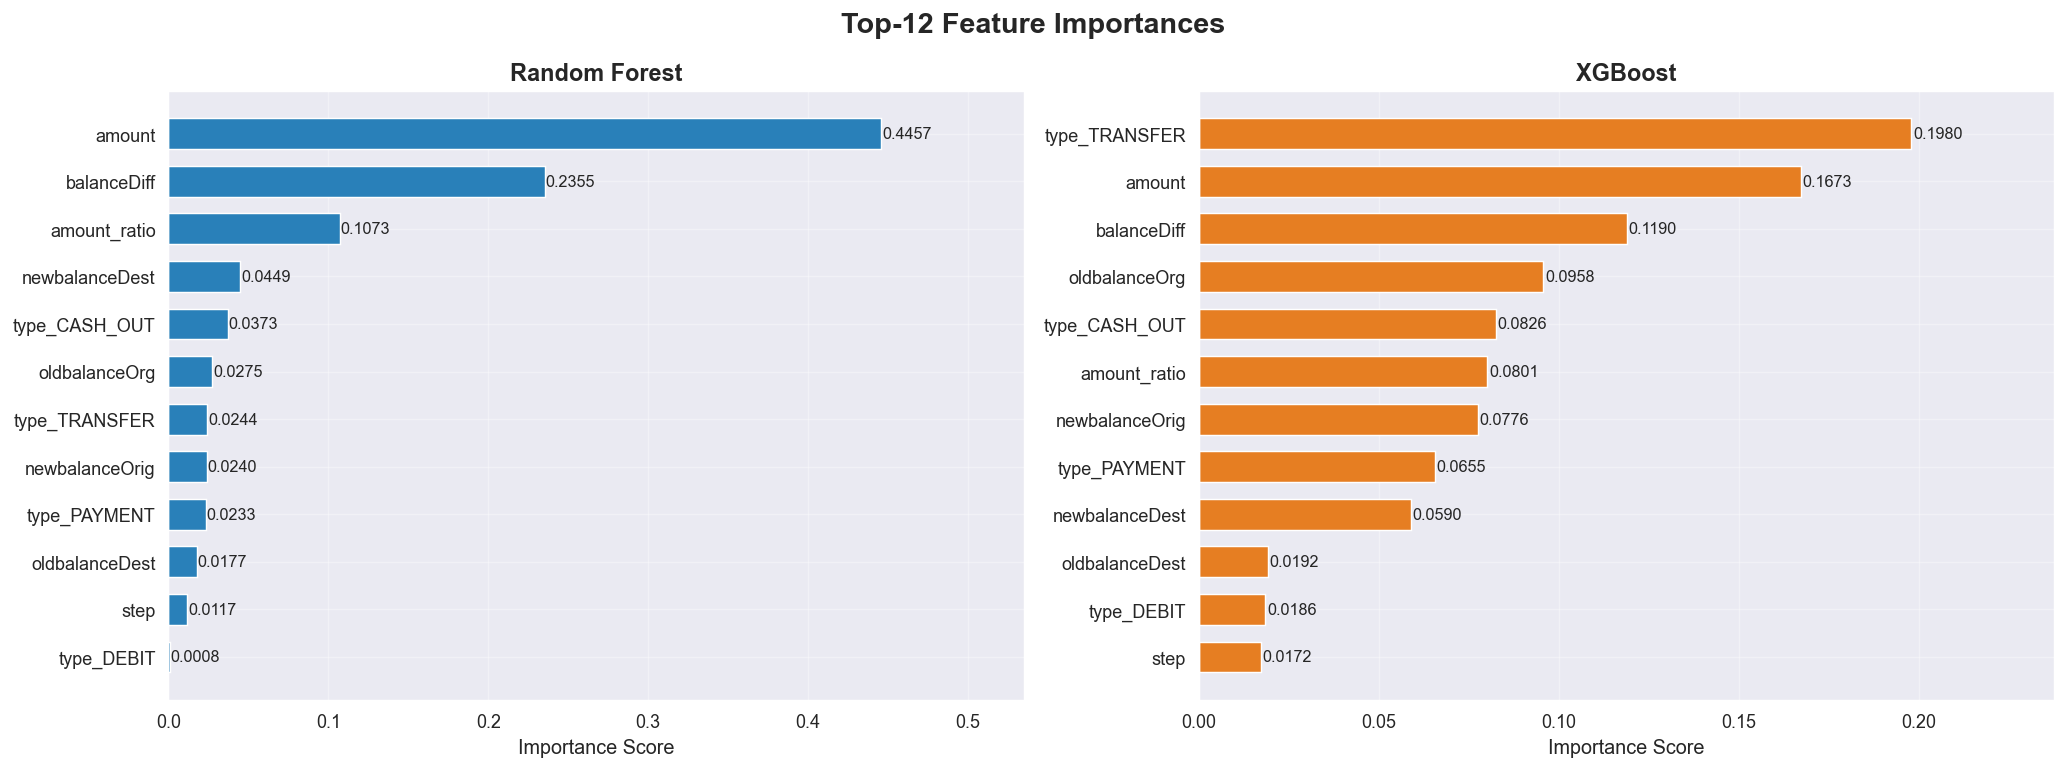

Feature importance charts saved.


In [95]:
plot_feature_importance(rf_model, xgb_model, FEATURE_NAMES)

## scripts/error_analysis.py
Identify where each model fails: analyse false positives and false negatives separately.

In [96]:
def error_analysis(model, model_name, X_test, y_test, feature_names):
    """
    Analyse False Positives (legitimate transactions flagged as fraud)
    and False Negatives (fraud transactions missed by the model).
    Prints key feature statistics for each error type.
    """
    y_pred = model.predict(X_test)
    df_err = pd.DataFrame(X_test, columns=feature_names)
    df_err['y_true'] = np.array(y_test)
    df_err['y_pred'] = y_pred

    fp = df_err[(df_err['y_true'] == 0) & (df_err['y_pred'] == 1)]
    fn = df_err[(df_err['y_true'] == 1) & (df_err['y_pred'] == 0)]
    total = len(df_err)

    print(f"\n{'='*58}")
    print(f"  ERROR ANALYSIS: {model_name.upper()}")
    print(f"{'='*58}")
    print(f"  Total test samples : {total:,}")
    print(f"  False Positives    : {len(fp):,} "
          f"({len(fp)/total*100:.2f}%)  — legit flagged as fraud")
    print(f"  False Negatives    : {len(fn):,} "
          f"({len(fn)/total*100:.2f}%)  — fraud missed by model")

    key_cols = ['amount', 'balanceDiff', 'amount_ratio']
    existing = [c for c in key_cols if c in feature_names]

    if existing:
        print("\n  ── False Positive Key Features ──")
        for col in existing:
            print(f"    {col:<18}: mean={fp[col].mean():.4f}  std={fp[col].std():.4f}")
        print("\n  ── False Negative Key Features ──")
        for col in existing:
            print(f"    {col:<18}: mean={fn[col].mean():.4f}  std={fn[col].std():.4f}")

    return fp, fn

In [97]:
# Run error analysis for all four models
lr_fp,  lr_fn  = error_analysis(lr_model,  "Logistic Regression", X_ts, y_ts, FEATURE_NAMES)
rf_fp,  rf_fn  = error_analysis(rf_model,  "Random Forest",       X_ts, y_ts, FEATURE_NAMES)
xgb_fp, xgb_fn = error_analysis(xgb_model, "XGBoost",             X_ts, y_ts, FEATURE_NAMES)
nn_fp,  nn_fn  = error_analysis(nn_model,  "Neural Network",      X_ts, y_ts, FEATURE_NAMES)



  ERROR ANALYSIS: LOGISTIC REGRESSION
  Total test samples : 1,272,524
  False Positives    : 147,323 (11.58%)  — legit flagged as fraud
  False Negatives    : 319 (0.03%)  — fraud missed by model

  ── False Positive Key Features ──
    amount            : mean=-0.0993  std=0.9622
    balanceDiff       : mean=0.4363  std=0.7275
    amount_ratio      : mean=-0.0740  std=1.0319

  ── False Negative Key Features ──
    amount            : mean=-0.2059  std=0.0421
    balanceDiff       : mean=0.3370  std=0.2005
    amount_ratio      : mean=-0.1097  std=0.0232

  ERROR ANALYSIS: RANDOM FOREST
  Total test samples : 1,272,524
  False Positives    : 86,166 (6.77%)  — legit flagged as fraud
  False Negatives    : 449 (0.04%)  — fraud missed by model

  ── False Positive Key Features ──
    amount            : mean=0.5844  std=2.4205
    balanceDiff       : mean=0.1936  std=0.4313
    amount_ratio      : mean=0.3784  std=2.3491

  ── False Negative Key Features ──
    amount            : mean

In [98]:
def plot_error_analysis(all_fps, all_fns, model_names, feature_names):
    """
    Bar chart of FP and FN counts per model.
    """
    fp_counts = [len(fp) for fp in all_fps]
    fn_counts = [len(fn) for fn in all_fns]

    x     = np.arange(len(model_names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))

    bars1 = ax.bar(x - width/2, fp_counts, width, color=C['orange'],
                   edgecolor='white', linewidth=1.2, label='False Positives (FP)')
    bars2 = ax.bar(x + width/2, fn_counts, width, color=C['red'],
                   edgecolor='white', linewidth=1.2, label='False Negatives (FN)')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylabel("Error Count", fontsize=12)
    ax.set_title("Error Analysis: False Positives vs False Negatives per Model",
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)

    plt.tight_layout()
    plt.savefig("outputs/plots/error_analysis.png", bbox_inches='tight')
    plt.show()
    plt.close('all')
    print("Error analysis chart saved.")


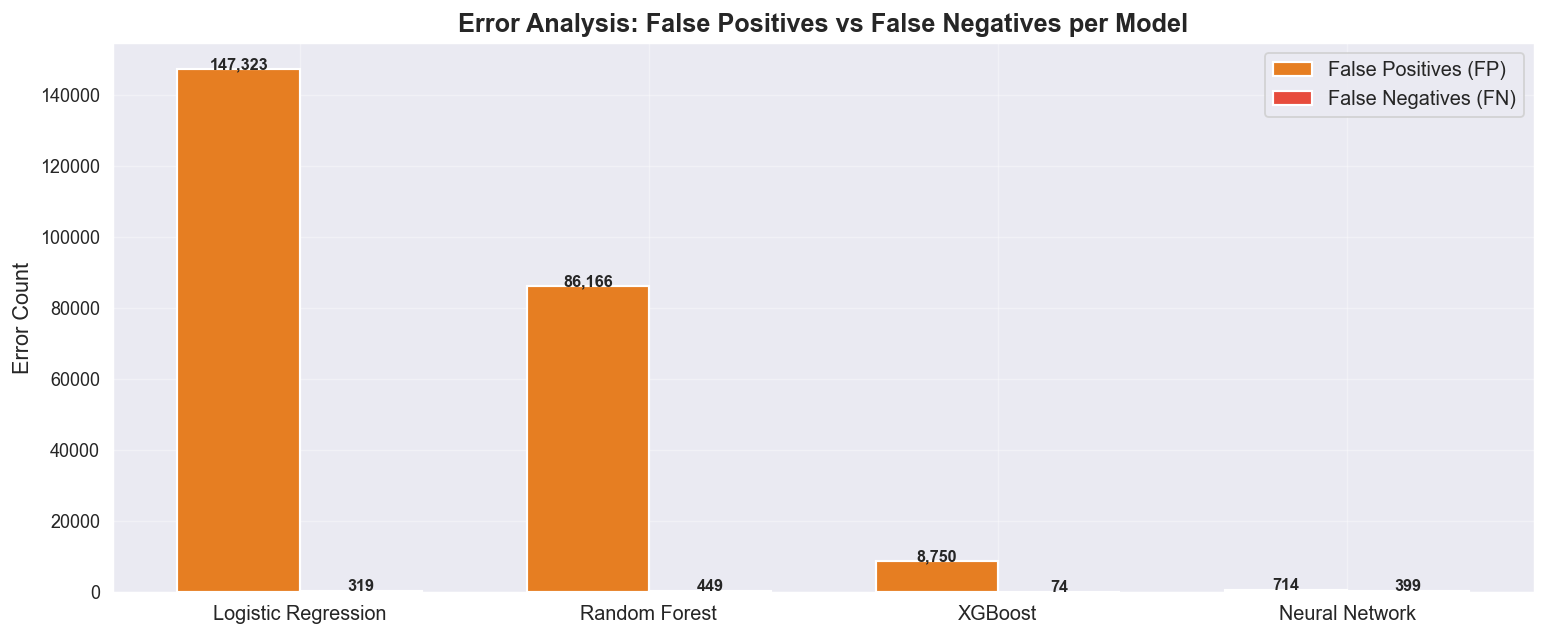

Error analysis chart saved.


In [99]:
plot_error_analysis(
    [lr_fp,  rf_fp,  xgb_fp, nn_fp],
    [lr_fn,  rf_fn,  xgb_fn, nn_fn],
    list(ALL_MODELS.keys()),
    FEATURE_NAMES,
)

## scripts/bias_check.py
Evaluate model performance across transaction types to detect systematic performance disparities — a critical fairness check.

In [100]:
print("Feature names:")
print(FEATURE_NAMES)
print("\nColumns with 'type':")
print([c for c in FEATURE_NAMES if 'type' in c.lower()])

Feature names:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiff', 'amount_ratio', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Columns with 'type':
['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [101]:
def bias_check(model, model_name, X_test, y_test, feature_names):
    """
    Evaluate fraud detection performance broken down by transaction type.
    Identifies whether the model is systematically biased toward or against
    specific transaction categories (TRANSFER, CASH_OUT, PAYMENT, etc.).
    """
    y_pred   = model.predict(X_test)
    df_bias  = pd.DataFrame(X_test, columns=feature_names)
    df_bias['y_true'] = np.array(y_test)
    df_bias['y_pred'] = y_pred

    type_cols = [c for c in feature_names if c.startswith('type_')]

    if not type_cols:
        print(f"{model_name}: no transaction-type columns found.")
        return None

    print(f"\n{'='*68}")
    print(f"  BIAS CHECK: {model_name.upper()}")
    print(f"{'='*68}")
    hdr = f"  {'Type':<18} {'Total':>7} {'Fraud':>7} {'Recall':>8} {'Precision':>11} {'F1':>7}"
    print(hdr)
    print("  " + "─" * 62)

    rows = []
    for col in type_cols:
        subset = df_bias[df_bias[col] == 1]
        if len(subset) == 0 or subset['y_true'].sum() == 0:
            continue
        rpt    = classification_report(
            subset['y_true'], subset['y_pred'],
            output_dict=True, zero_division=0
        )
        fm     = rpt.get('1', {'precision': 0, 'recall': 0, 'f1-score': 0})
        label  = col.replace('type_', '')
        print(f"  {label:<18} {len(subset):>7,} {int(subset['y_true'].sum()):>7,} "
              f"{fm['recall']:>8.3f} {fm['precision']:>11.3f} {fm['f1-score']:>7.3f}")
        rows.append({
            'type': label, 'total': len(subset),
            'fraud_count': int(subset['y_true'].sum()),
            'recall': fm['recall'], 'precision': fm['precision'], 'f1': fm['f1-score'],
        })

    return pd.DataFrame(rows)

In [102]:
bias_lr  = bias_check(lr_model,  "Logistic Regression", X_test, y_test, FEATURE_NAMES)
bias_rf  = bias_check(rf_model,  "Random Forest",       X_test, y_test, FEATURE_NAMES)
bias_xgb = bias_check(xgb_model, "XGBoost",             X_test, y_test, FEATURE_NAMES)
bias_nn  = bias_check(nn_model,  "Neural Network",      X_test, y_test, FEATURE_NAMES)


  BIAS CHECK: LOGISTIC REGRESSION
  Type                 Total   Fraud   Recall   Precision      F1
  ──────────────────────────────────────────────────────────────
  CASH_OUT           447,193     798    0.008       0.001   0.002
  TRANSFER           106,527     845    0.994       0.526   0.688

  BIAS CHECK: RANDOM FOREST
  Type                 Total   Fraud   Recall   Precision      F1
  ──────────────────────────────────────────────────────────────
  CASH_OUT           447,193     798    1.000       0.002   0.004
  TRANSFER           106,527     845    1.000       0.008   0.016

  BIAS CHECK: XGBOOST
  Type                 Total   Fraud   Recall   Precision      F1
  ──────────────────────────────────────────────────────────────
  CASH_OUT           447,193     798    1.000       0.002   0.004
  TRANSFER           106,527     845    1.000       0.008   0.016

  BIAS CHECK: NEURAL NETWORK
  Type                 Total   Fraud   Recall   Precision      F1
  ──────────────────────────

In [103]:
def plot_bias_check(bias_dfs, model_names):
    """
    Grouped bar chart of Recall and F1-Score by transaction type per model.
    """
    type_color = {
        'CASH_IN' : C['green'],  'CASH_OUT': C['red'],
        'DEBIT'   : C['blue'],   'PAYMENT' : C['teal'],
        'TRANSFER': C['orange'], 'DEFAULT' : C['gray'],
    }

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    axes = axes.flatten()

    for ax, (name, bdf) in zip(axes, zip(model_names, bias_dfs)):
        if bdf is None or len(bdf) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=13)
            ax.set_title(name, fontsize=13, fontweight='bold')
            continue

        x      = np.arange(len(bdf))
        width  = 0.35
        colors = [type_color.get(t, C['gray']) for t in bdf['type']]

        bars_r = ax.bar(x - width/2, bdf['recall'],    width, color=colors,
                        alpha=0.85, edgecolor='white', linewidth=1, label='Recall')
        bars_f = ax.bar(x + width/2, bdf['f1'],        width, color=colors,
                        alpha=0.50, edgecolor='white', linewidth=1,
                        hatch='///', label='F1-Score')

        for bars in [bars_r, bars_f]:
            for bar in bars:
                if bar.get_height() > 0.02:
                    ax.text(bar.get_x() + bar.get_width()/2,
                            bar.get_height() + 0.01,
                            f'{bar.get_height():.2f}',
                            ha='center', fontsize=8, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(bdf['type'], fontsize=10)
        ax.set_ylim(0, 1.22)
        ax.set_ylabel("Score", fontsize=10)
        ax.set_title(name, fontsize=13, fontweight='bold')
        ax.legend(fontsize=9)

    fig.suptitle("Bias Check: Recall & F1-Score by Transaction Type",
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("outputs/plots/bias_check.png", bbox_inches='tight')
    plt.show()
    plt.close('all')
    print("Bias check chart saved.")


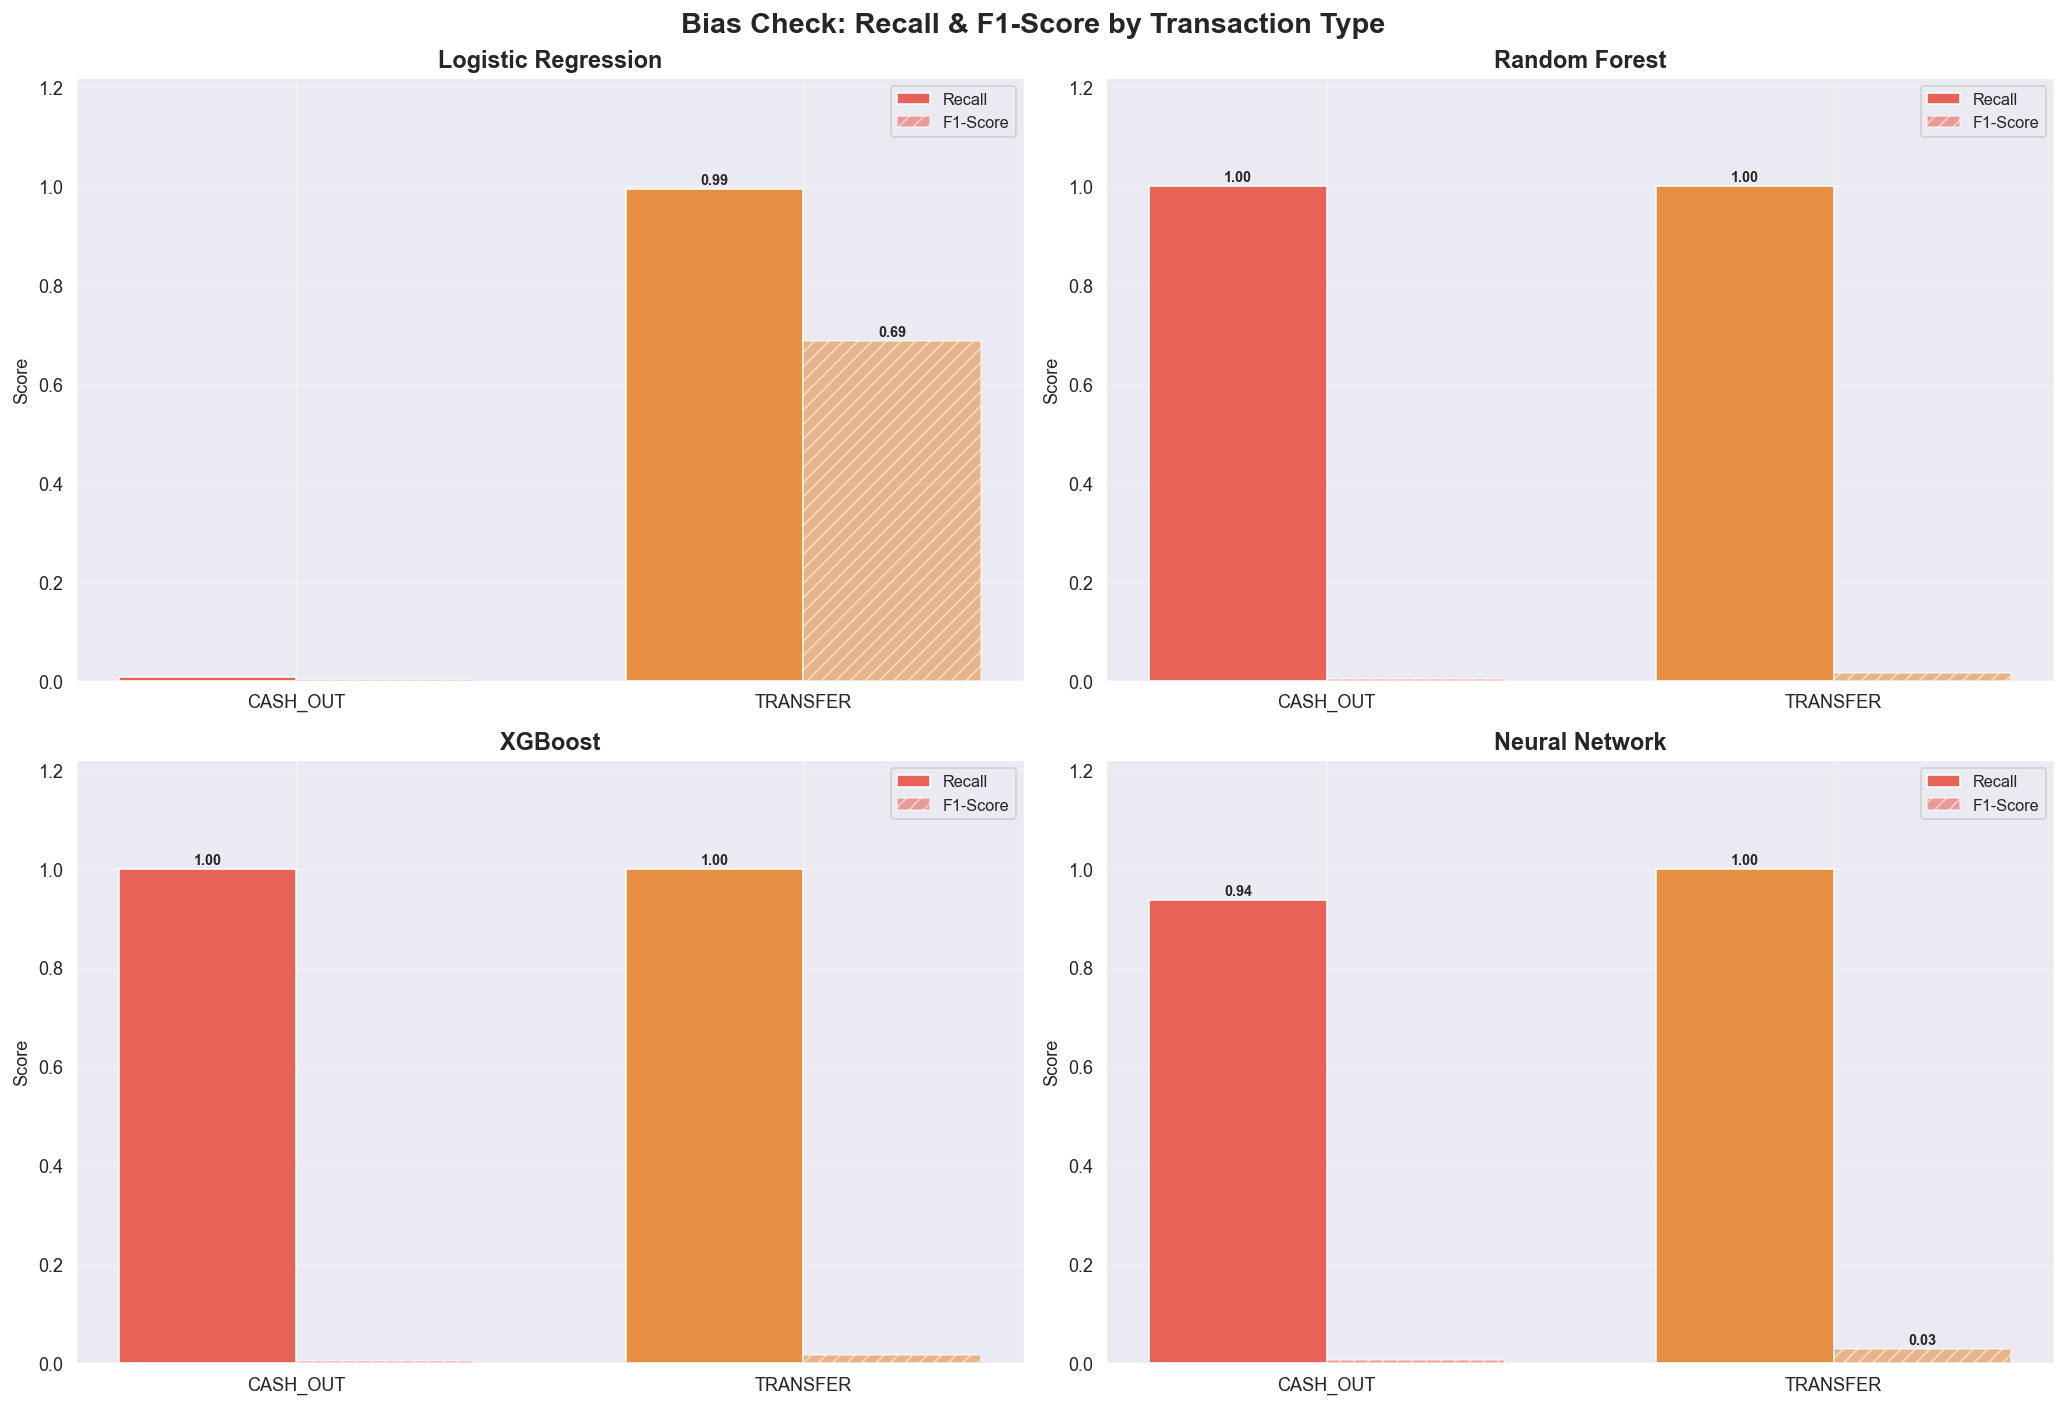

Bias check chart saved.


In [104]:
plot_bias_check(
    [bias_lr, bias_rf, bias_xgb, bias_nn],
    list(ALL_MODELS.keys()),
)

## scripts/compare_model.py

In [105]:
def compare_models(all_metrics):
    """
    Aggregate CV and test metrics for all models into a comparison table.
    Sorted by Test F1-Score (fraud class) descending.
    """
    rows = []
    for name, m in all_metrics.items():
        rows.append({
            "Model"             : name,
            "CV Precision"      : f"{m['cv_precision_mean']:.3f} ± {m['cv_precision_std']:.3f}",
            "CV Recall"         : f"{m['cv_recall_mean']:.3f} ± {m['cv_recall_std']:.3f}",
            "CV F1"             : f"{m['cv_f1_mean']:.3f} ± {m['cv_f1_std']:.3f}",
            "CV AUC-ROC"        : f"{m['cv_auc_mean']:.3f} ± {m['cv_auc_std']:.3f}",
            "Test Precision"    : round(m['test_precision'], 4),
            "Test Recall"       : round(m['test_recall'],    4),
            "Test F1"           : round(m['test_f1'],        4),
            "Test AUC-ROC"      : round(m['test_auc_roc'],   4),
        })

    df_cmp = (pd.DataFrame(rows)
                .sort_values("Test F1", ascending=False)
                .reset_index(drop=True))

    print("\n" + "=" * 92)
    print("  MODEL COMPARISON TABLE  (sorted by Test F1 ↓)")
    print("=" * 92)
    print(df_cmp.to_string(index=False))
    print("=" * 92)

    best = df_cmp.iloc[0]
    print(f"\n  🏆 BEST MODEL : {best['Model']}")
    print(f"     Test F1    : {best['Test F1']}")
    print(f"     Test AUC   : {best['Test AUC-ROC']}")
    print(f"     Test Recall: {best['Test Recall']}")

    df_cmp.to_csv("outputs/metrics/model_comparison.csv", index=False)
    print("\n  Comparison table saved to outputs/metrics/model_comparison.csv")

    return df_cmp


In [106]:
df_compare = compare_models(ALL_METRICS)


  MODEL COMPARISON TABLE  (sorted by Test F1 ↓)
              Model  CV Precision     CV Recall         CV F1    CV AUC-ROC  Test Precision  Test Recall  Test F1  Test AUC-ROC
     Neural Network 0.988 ± 0.004 0.925 ± 0.009 0.955 ± 0.004 0.997 ± 0.001          0.6353       0.7572   0.6909        0.9921
            XGBoost 0.992 ± 0.000 0.871 ± 0.004 0.928 ± 0.002 0.996 ± 0.000          0.1520       0.9550   0.2623        0.9979
      Random Forest 0.538 ± 0.008 0.802 ± 0.006 0.644 ± 0.004 0.944 ± 0.001          0.0137       0.7267   0.0268        0.8621
Logistic Regression 0.375 ± 0.001 0.696 ± 0.002 0.487 ± 0.001 0.883 ± 0.000          0.0089       0.8058   0.0176        0.9035

  🏆 BEST MODEL : Neural Network
     Test F1    : 0.6909
     Test AUC   : 0.9921
     Test Recall: 0.7572

  Comparison table saved to outputs/metrics/model_comparison.csv


In [107]:
def plot_model_comparison(df_compare):
    """
    4-panel bar chart: one panel per key test metric.
    """
    metrics = ['Test Precision', 'Test Recall', 'Test F1', 'Test AUC-ROC']
    labels  = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    colors  = [C['blue'], C['red'], C['green'], C['orange']]
    models  = df_compare['Model'].tolist()

    fig, axes = plt.subplots(1, 4, figsize=(19, 5))

    for ax, metric, label, color in zip(axes, metrics, labels, colors):
        vals = df_compare[metric].tolist()
        bars = ax.bar(models, vals, color=color, edgecolor='white',
                      linewidth=1.2, width=0.5)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=9.5, fontweight='bold')
        ax.set_title(label, fontsize=13, fontweight='bold')
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.15)
        ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)

    fig.suptitle("Model Comparison — Test Set Metrics", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("outputs/plots/model_comparison_bars.png", bbox_inches='tight')
    plt.show()
    plt.close('all')
    print("Model comparison bar chart saved.")


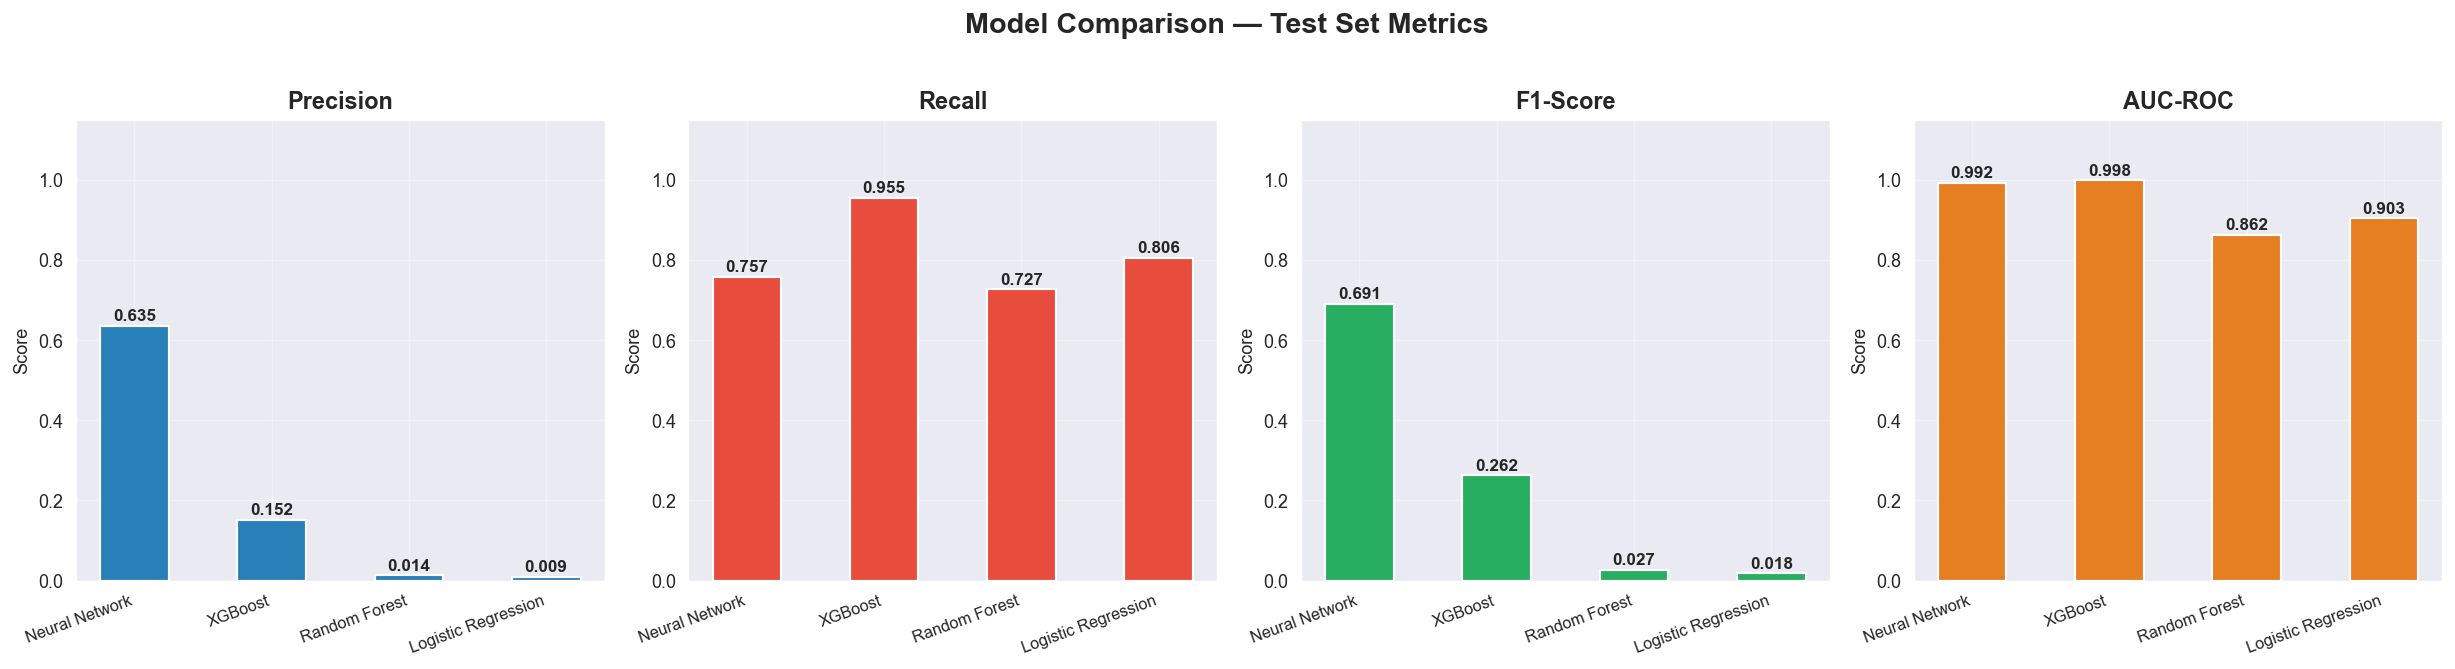

Model comparison bar chart saved.


In [108]:
plot_model_comparison(df_compare)

## scripts/compare_model.py


In [123]:
def threshold_optimization(model, X_test, y_test, model_name="Model"):
    """Find optimal decision threshold that balances precision, recall, and F1."""
    print(f"\n{'='*70}")
    print(f"  THRESHOLD OPTIMIZATION: {model_name.upper()}")
    print(f"{'='*70}")
    
    y_proba = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0, 1, 100)
    precisions, recalls, f1_scores = [], [], []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        if len(np.unique(y_pred)) == 1:
            precisions.append(0)
            recalls.append(0)
            f1_scores.append(0)
            continue
        
        tn = np.sum((y_pred == 0) & (y_test == 0))
        fp = np.sum((y_pred == 1) & (y_test == 0))
        fn = np.sum((y_pred == 0) & (y_test == 1))
        tp = np.sum((y_pred == 1) & (y_test == 1))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]
    optimal_precision = precisions[optimal_idx]
    optimal_recall = recalls[optimal_idx]
    
    print(f"\nOptimal Threshold: {optimal_threshold:.3f}")
    print(f"  Precision: {optimal_precision:.4f}")
    print(f"  Recall:    {optimal_recall:.4f}")
    print(f"  F1-Score:  {optimal_f1:.4f}")
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(thresholds, precisions, label='Precision', linewidth=2)
    plt.plot(thresholds, recalls, label='Recall', linewidth=2)
    plt.plot(thresholds, f1_scores, label='F1-Score', linewidth=2, linestyle='--')
    plt.axvline(optimal_threshold, color='red', linestyle=':', linewidth=2, label=f'Optimal ({optimal_threshold:.3f})')
    plt.xlabel('Decision Threshold', fontsize=11)
    plt.ylabel('Score', fontsize=11)
    plt.title(f'{model_name} - Metrics vs Threshold', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(recalls, precisions, linewidth=2, color='purple')
    plt.scatter([optimal_recall], [optimal_precision], color='red', s=100, zorder=5)
    plt.xlabel('Recall', fontsize=11)
    plt.ylabel('Precision', fontsize=11)
    plt.title(f'{model_name} - Precision-Recall Curve', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'outputs/plots/threshold_optimization_{model_name.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return optimal_threshold, optimal_f1


  THRESHOLD OPTIMIZATION: NEURAL NETWORK

Optimal Threshold: 1.000
  Precision: 0.0017
  Recall:    0.9684
  F1-Score:  0.0034


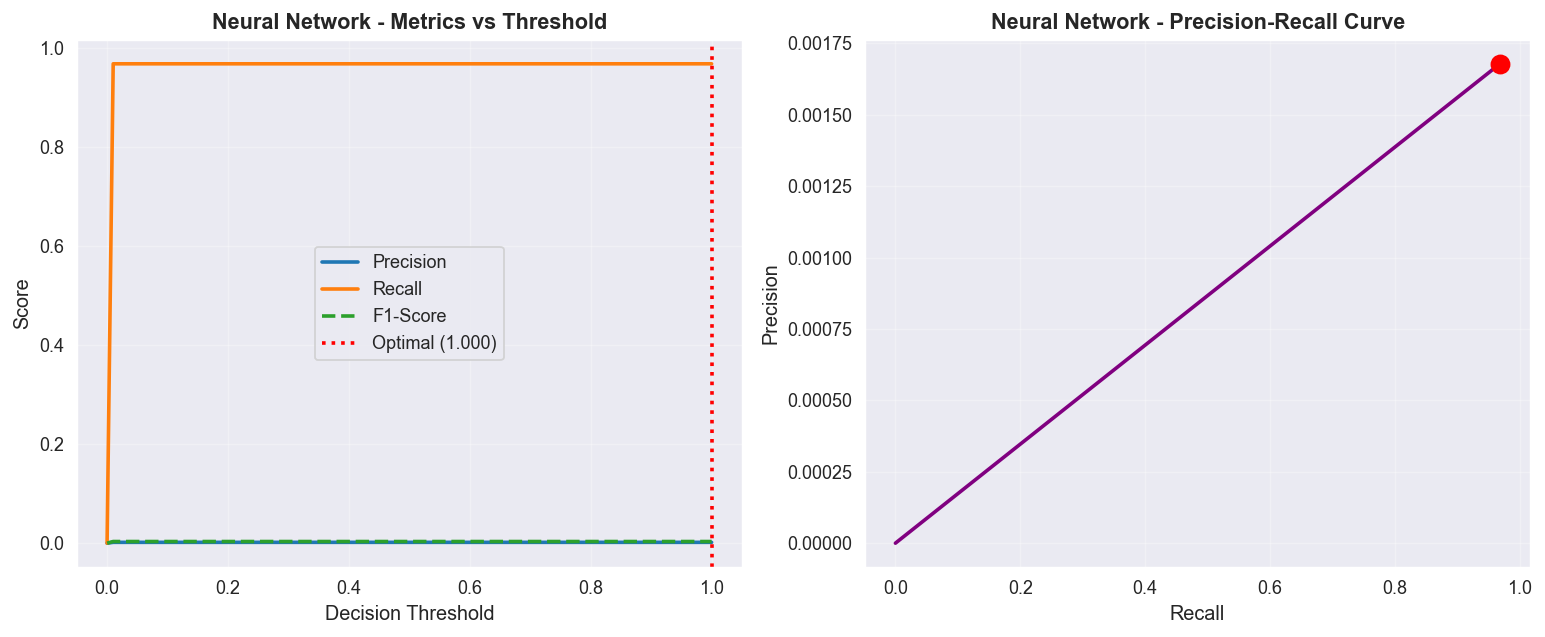

In [124]:
optimal_threshold, optimal_f1 = threshold_optimization(nn_model, X_test, y_test, "Neural Network")

In [127]:
# For Neural Networks, extract from training data patterns instead
print(f"\n{'='*70}")
print(f"  INTERPRETABILITY ANALYSIS: NEURAL NETWORK")
print(f"{'='*70}")

# NN doesn't have feature_importances_, so calculate from predictions
y_proba = nn_model.predict_proba(X_test)[:, 1]

# Show which features correlate with fraud predictions
print("\nFeature Statistics for Fraud vs Legitimate:")
print(f"{'Feature':<20} {'Fraud Mean':>12} {'Legit Mean':>12} {'Difference':>12}")
print("-" * 58)

fraud_mask = (nn_model.predict(X_test) == 1)
legit_mask = (nn_model.predict(X_test) == 0)

for i, feat_name in enumerate(FEATURE_NAMES):
    if hasattr(X_test, 'iloc'):
        fraud_mean = X_test.iloc[fraud_mask, i].mean()
        legit_mean = X_test.iloc[legit_mask, i].mean()
    else:
        fraud_mean = X_test[fraud_mask, i].mean()
        legit_mean = X_test[legit_mask, i].mean()
    
    diff = abs(fraud_mean - legit_mean)
    print(f"{feat_name:<20} {fraud_mean:>12.4f} {legit_mean:>12.4f} {diff:>12.4f}")


  INTERPRETABILITY ANALYSIS: NEURAL NETWORK

Feature Statistics for Fraud vs Legitimate:
Feature                Fraud Mean   Legit Mean   Difference
----------------------------------------------------------
step                     244.4470     240.8746       3.5724
amount                164003.6250  225426.2656   61422.6406
oldbalanceOrg         859791.1875  760389.4375   99401.7500
newbalanceOrig        887310.9375  763713.4375  123597.5000
oldbalanceDest        413124.2188 3113670.7500 2700546.5000
newbalanceDest        488837.4062 3378034.0000 2889196.5000
balanceDiff           -27519.6289   -3323.9927   24195.6367
amount_ratio           39865.0586  160358.5625  120493.5000
type_CASH_OUT              0.2322       0.6997       0.4675
type_DEBIT                 0.0019       0.0199       0.0179
type_PAYMENT               0.4511       0.0081       0.4430
type_TRANSFER              0.0611       0.1498       0.0887


In [128]:
def explain_fraud_cases(model, X_test, y_test, feature_names, model_name="Model", n_examples=5):
    """Show why model flagged specific transactions as fraud."""
    print(f"\n{'='*70}")
    print(f"  EXAMPLE FRAUD CASES: {model_name.upper()}")
    print(f"{'='*70}")
    
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    fraud_mask = (y_pred == 1) & (y_test == 1)
    fraud_indices = np.where(fraud_mask)[0]
    
    if len(fraud_indices) == 0:
        print("No fraud cases detected in test set")
        return
    
    fraud_indices = fraud_indices[np.argsort(y_proba[fraud_indices])[::-1]][:n_examples]
    
    print(f"\nShowing {min(n_examples, len(fraud_indices))} high-confidence fraud cases:")
    for i, idx in enumerate(fraud_indices):
        print(f"\n  Case {i+1}:")
        print(f"    Fraud Probability: {y_proba[idx]:.4f}")
        
        if hasattr(model, 'feature_importances_'):
            top_features = np.argsort(model.feature_importances_)[::-1][:3]
            print(f"    Top contributing features:")
            for feat_idx in top_features:
                value = X_test.iloc[idx, feat_idx] if hasattr(X_test, 'iloc') else X_test[idx, feat_idx]
                print(f"      - {feature_names[feat_idx]}: {value:.4f}")

print("Analysis functions loaded!")

Analysis functions loaded!


In [129]:
explain_fraud_cases(nn_model, X_test, y_test, FEATURE_NAMES, "Neural Network", n_examples=10)


  EXAMPLE FRAUD CASES: NEURAL NETWORK

Showing 10 high-confidence fraud cases:

  Case 1:
    Fraud Probability: 1.0000

  Case 2:
    Fraud Probability: 1.0000

  Case 3:
    Fraud Probability: 1.0000

  Case 4:
    Fraud Probability: 1.0000

  Case 5:
    Fraud Probability: 1.0000

  Case 6:
    Fraud Probability: 1.0000

  Case 7:
    Fraud Probability: 1.0000

  Case 8:
    Fraud Probability: 1.0000

  Case 9:
    Fraud Probability: 1.0000

  Case 10:
    Fraud Probability: 1.0000


In [133]:
print("\n" + "="*70)
print("DETAILED FRAUD CASE ANALYSIS")
print("="*70)

# Get fraud cases
y_proba = nn_model.predict_proba(X_test)[:, 1]
y_pred = nn_model.predict(X_test)
fraud_mask = (y_pred == 1) & (y_test == 1)
fraud_indices = np.where(fraud_mask)[0]

# Show top 5 fraud cases
for i, idx in enumerate(fraud_indices[:5]):
    print(f"\n Case {i+1} (Fraud Probability: {y_proba[idx]:.4f}):")
    print("  Features:")
    
    for j, feat_name in enumerate(FEATURE_NAMES):
        value = X_test.iloc[idx, j] if hasattr(X_test, 'iloc') else X_test[idx, j]
        print(f"    {feat_name:<20}: {value:>12.4f}")


DETAILED FRAUD CASE ANALYSIS

 Case 1 (Fraud Probability: 1.0000):
  Features:
    step                :     583.0000
    amount              :  759701.0000
    oldbalanceOrg       :  759701.0000
    newbalanceOrig      :       0.0000
    oldbalanceDest      : 1076095.6250
    newbalanceDest      : 1835796.7500
    balanceDiff         :  759701.0000
    amount_ratio        :       1.0000
    type_CASH_OUT       :       1.0000
    type_DEBIT          :       0.0000
    type_PAYMENT        :       0.0000
    type_TRANSFER       :       0.0000

 Case 2 (Fraud Probability: 1.0000):
  Features:
    step                :      22.0000
    amount              :  235512.2031
    oldbalanceOrg       :  235512.2031
    newbalanceOrig      :       0.0000
    oldbalanceDest      :       0.0000
    newbalanceDest      :       0.0000
    balanceDiff         :  235512.2031
    amount_ratio        :       1.0000
    type_CASH_OUT       :       0.0000
    type_DEBIT          :       0.0000
    type_PAY

In [130]:
print_memory("[PIPELINE COMPLETE]")
print("\nAll done! Models, metrics, and plots saved in outputs/")

  Memory Usage [PIPELINE COMPLETE]           :      179 MB

All done! Models, metrics, and plots saved in outputs/
